## Exploracao dos resultados de capital

In [579]:
import math
from itertools import combinations
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency, chisquare, friedmanchisquare, pearsonr, ttest_1samp, wilcoxon
from IPython.display import Markdown, display
from statsmodels.stats.proportion import proportions_chisquare, proportions_chisquare_allpairs
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

ESTATISTICAS_DIR = ROOT / "data" / "estatisticas"
ESTATISTICAS_DIR.mkdir(parents=True, exist_ok=True)
RESULTADOS_DIR = ESTATISTICAS_DIR / "alinhado_precision"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

MESES_PT = {
    1: "Jan",
    2: "Fev",
    3: "Mar",
    4: "Abr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Set",
    10: "Out",
    11: "Nov",
    12: "Dez",
}

OTIMIZACOES = {
    "1/n": {
        "capital_col": "total_verdadeiro",
        "folder_ensemble": ROOT / "data/ensemble/11_otimi",
        "folder_tecnicas": ROOT / "data/tecnicas/otimi_tecnicas_6",
        "metodo_transacao": "bin_aux",
    },
    "MV Sharpe": {
        "capital_col": "capital_total_mv_sharpe",
        "folder_ensemble": ROOT / "data/ensemble/16_capital_mv_sharpe",
        "folder_tecnicas": ROOT / "data/tecnicas/capital_mv_sharpe_tecnicas_10",
        "metodo_transacao": "peso_alocacao_mv_sharpe",
    },
    "Min Variancia": {
        "capital_col": "capital_total_min_variancia",
        "folder_ensemble": ROOT / "data/ensemble/17_capital_mv_min_variancia",
        "folder_tecnicas": ROOT / "data/tecnicas/capital_mv_min_variancia_tecnicas_11",
        "metodo_transacao": "peso_alocacao_min_variancia",
    },
}

ENSEMBLE_TECNICAS = ["esmble_jan_tot", "esmble_jan_par", "in_precision"]
ENSEMBLE_TECNICAS_LABEL = {
    "esmble_jan_tot": "Ensemble total",
    "esmble_jan_par": "Ensemble parcial",
    "in_precision": "Precision",
}

FAMILIAS = ["RNA", "SVC", "RandomForest"]
FAMILIAS_LABEL = {
    "RNA": "RNA",
    "SVC": "SVC",
    "RandomForest": "Random Forest",
}

JANELAS = ["60", "75", "90"]
TARGETS = ["1_01", "1_015", "1_02"]
TARGETS_LABEL = {
    "1_01": "1.01",
    "1_015": "1.015",
    "1_02": "1.02",
}

CORES_TECNICAS = {
    "esmble_jan_tot": "#0f4c81",
    "esmble_jan_par": "#32845d",
    "in_precision": "#c05621",
}

CORES_TARGETS = {
    "1_01": "#0f4c81",
    "1_015": "#32845d",
    "1_02": "#c05621",
}

def formatar_pvalor(p_valor):
    if pd.isna(p_valor):
        return "NA"
    if p_valor < 0.001:
        return "< 0.001"
    return f"{p_valor:.3f}"


def testar_superacao_mensal_benchmark(comparacao, benchmark_col):
    resultados = []

    for serie_label, grupo in comparacao.groupby("serie_label"):
        retorno_modelo = pd.to_numeric(grupo["rentabilidade_mensal"], errors="coerce")
        retorno_benchmark = pd.to_numeric(grupo[benchmark_col], errors="coerce")
        base = pd.DataFrame({
            "retorno_modelo": retorno_modelo,
            "retorno_benchmark": retorno_benchmark,
        }).dropna()

        if base.empty:
            continue

        base = base[(1 + base["retorno_modelo"] > 0) & (1 + base["retorno_benchmark"] > 0)].copy()
        if base.empty:
            continue

        base["log_modelo"] = np.log1p(base["retorno_modelo"])
        base["log_benchmark"] = np.log1p(base["retorno_benchmark"])
        base["diferenca_log"] = base["log_modelo"] - base["log_benchmark"]

        diferencas = base["diferenca_log"].dropna()
        n = len(diferencas)

        crescimento_geometrico_modelo = np.expm1(base["log_modelo"].mean())
        crescimento_geometrico_benchmark = np.expm1(base["log_benchmark"].mean())
        diferencial_crescimento = crescimento_geometrico_modelo - crescimento_geometrico_benchmark

        if n > 1 and not np.allclose(diferencas, diferencas.iloc[0]):
            teste = ttest_1samp(diferencas, popmean=0.0, alternative="greater")
            estatistica_t = float(teste.statistic)
            p_valor_t = float(teste.pvalue)
        elif n >= 1:
            estatistica_t = np.nan
            p_valor_t = 0.0 if diferencas.mean() > 0 else 1.0
        else:
            estatistica_t = np.nan
            p_valor_t = np.nan

        resultados.append({
            "serie_label": serie_label,
            "meses_comparados": n,
            "crescimento_medio_mensal_modelo": crescimento_geometrico_modelo,
            "crescimento_medio_mensal_benchmark": crescimento_geometrico_benchmark,
            "diferencial_crescimento_medio_mensal": diferencial_crescimento,
            "estatistica_t": estatistica_t,
            "p_valor_t": p_valor_t,
        })

    resultados = pd.DataFrame(resultados)
    if resultados.empty:
        return resultados

    resultados["crescimento_medio_mensal_modelo_percentual"] = resultados["crescimento_medio_mensal_modelo"] * 100
    resultados["crescimento_medio_mensal_benchmark_percentual"] = resultados["crescimento_medio_mensal_benchmark"] * 100
    resultados["diferencial_crescimento_medio_mensal_percentual"] = resultados["diferencial_crescimento_medio_mensal"] * 100
    resultados["significativo_t_5pct"] = resultados["p_valor_t"] < 0.05
    return resultados.sort_values(["significativo_t_5pct", "diferencial_crescimento_medio_mensal"], ascending=[False, False]).reset_index(drop=True)


def testar_distribuicao_uniforme(contagem, labels=None):
    contagem = pd.Series(contagem).fillna(0)
    if labels is not None:
        contagem.index = labels

    total = contagem.sum()
    esperado = np.repeat(total / len(contagem), len(contagem)) if len(contagem) else np.array([])

    if len(contagem) > 0 and total > 0:
        estatistica, p_valor = chisquare(contagem.values, f_exp=esperado)
    else:
        estatistica, p_valor = np.nan, np.nan

    tabela = pd.DataFrame({
        "categoria": contagem.index.astype(str),
        "observado": contagem.values,
        "esperado_uniforme": esperado,
        "desvio_observado_menos_esperado": contagem.values - esperado,
    })
    return tabela, estatistica, p_valor


def testar_igualdade_proporcoes_sinais(analise_sinais):
    base = analise_sinais.copy()
    base = base.dropna(subset=["sinais_possiveis_totais", "sinais_positivos_gerados"]).copy()

    contagens = base["sinais_positivos_gerados"].astype(float).to_numpy()
    nobs = base["sinais_possiveis_totais"].astype(float).to_numpy()

    if len(base) > 1 and np.all(nobs > 0):
        estatistica, p_valor, tabela = proportions_chisquare(count=contagens, nobs=nobs)
    else:
        estatistica, p_valor, tabela = np.nan, np.nan, None

    proporcao_global = contagens.sum() / nobs.sum() if np.all(np.isfinite(nobs)) and nobs.sum() > 0 else np.nan
    base["proporcao_global_percentual"] = proporcao_global * 100 if pd.notna(proporcao_global) else np.nan
    base["desvio_em_relacao_a_global_percentual"] = base["proporcao_sinais_positivos_percentual"] - base["proporcao_global_percentual"]

    return base, estatistica, p_valor


In [580]:
def parse_ensemble_filename(path):
    match = re.match(r"^(esmble_jan_tot|esmble_jan_par|in_precision)_target_(1_01|1_015|1_02)\.csv$", path.name)
    if not match:
        return None

    tecnica, target = match.groups()
    return {
        "universo": "ensemble",
        "tecnica": tecnica,
        "target": target,
        "familia": None,
        "janela": None,
    }


def parse_tecnica_filename(path):
    match = re.match(r"^(RNA|SVC|RandomForest)_(60|75|90)_target_(1_01|1_015|1_02)\.csv$", path.name)
    if not match:
        return None

    familia, janela, target = match.groups()
    return {
        "universo": "tecnicas",
        "tecnica": None,
        "target": target,
        "familia": familia,
        "janela": janela,
    }


def extrair_transacoes_diarias(df, metodo_transacao):
    if metodo_transacao == "bin_aux":
        cols = [col for col in df.columns if col.startswith("bin_aux_")]
        if not cols:
            return pd.Series(np.zeros(len(df), dtype=int), index=df.index)
        return (df[cols].apply(pd.to_numeric, errors="coerce").fillna(0) > 0).sum(axis=1).astype(int)

    sufixo = metodo_transacao.replace("peso_alocacao_", "")
    cols = [col for col in df.columns if col.startswith("peso_alocacao_") and col.endswith(f"_{sufixo}")]
    if not cols:
        return pd.Series(np.zeros(len(df), dtype=int), index=df.index)
    return (df[cols].apply(pd.to_numeric, errors="coerce").fillna(0) > 1e-12).sum(axis=1).astype(int)


def carregar_serie(path, optimization_name, config, parser):
    meta = parser(path)
    if meta is None:
        return None

    df = pd.read_csv(path)
    if "data" not in df.columns or config["capital_col"] not in df.columns:
        return None

    df["data"] = pd.to_datetime(df["data"], errors="coerce")
    df[config["capital_col"]] = pd.to_numeric(df[config["capital_col"]], errors="coerce")
    df = df.dropna(subset=["data", config["capital_col"]]).sort_values("data").reset_index(drop=True)

    transacoes_diarias = extrair_transacoes_diarias(df, config["metodo_transacao"])

    daily = pd.DataFrame(
        {
            "data": df["data"],
            "capital": df[config["capital_col"]],
            "transacoes_dia": transacoes_diarias,
        }
    )

    monthly = daily.set_index("data").resample("ME").agg(
        capital_fim_mes=("capital", "last"),
        transacoes_mensais=("transacoes_dia", "sum"),
    )
    monthly["rentabilidade_mensal"] = monthly["capital_fim_mes"].pct_change()
    monthly = monthly.reset_index().rename(columns={"data": "mes_referencia"})

    meta.update(
        {
            "optimization": optimization_name,
            "capital_col": config["capital_col"],
            "path": path,
            "daily": daily,
            "monthly": monthly,
        }
    )

    if meta["universo"] == "ensemble":
        meta["serie_id"] = f"ensemble|{optimization_name}|{meta['tecnica']}|{meta['target']}"
        meta["serie_label"] = f"{ENSEMBLE_TECNICAS_LABEL[meta['tecnica']]} | target {TARGETS_LABEL[meta['target']]} | {optimization_name}"
        meta["grupo_label"] = f"Ensemble | {optimization_name}"
    else:
        meta["serie_id"] = f"{meta['familia']}|{optimization_name}|{meta['janela']}|{meta['target']}"
        meta["serie_label"] = f"{FAMILIAS_LABEL[meta['familia']]} | janela {meta['janela']} | target {TARGETS_LABEL[meta['target']]} | {optimization_name}"
        meta["grupo_label"] = f"{FAMILIAS_LABEL[meta['familia']]} | {optimization_name}"

    return meta


def carregar_todas_as_series():
    series = {}

    for optimization_name, config in OTIMIZACOES.items():
        for path in sorted(config["folder_ensemble"].glob("*.csv")):
            info = carregar_serie(path, optimization_name, config, parse_ensemble_filename)
            if info is not None:
                series[info["serie_id"]] = info

        for path in sorted(config["folder_tecnicas"].glob("*.csv")):
            info = carregar_serie(path, optimization_name, config, parse_tecnica_filename)
            if info is not None:
                series[info["serie_id"]] = info

    return series


SERIES = carregar_todas_as_series()
len(SERIES)

precision_end_dates = [
    info["daily"]["data"].max()
    for info in SERIES.values()
    if info.get("tecnica") == "in_precision" and not info["daily"].empty
]

DATA_FINAL_COMUM = min(precision_end_dates) if precision_end_dates else None

if DATA_FINAL_COMUM is not None:
    for info in SERIES.values():
        info["daily"] = (
            info["daily"][info["daily"]["data"] <= DATA_FINAL_COMUM]
            .copy()
            .reset_index(drop=True)
        )

        monthly = (
            info["daily"]
            .set_index("data")
            .resample("ME")
            .agg(
                capital_fim_mes=("capital", "last"),
                transacoes_mensais=("transacoes_dia", "sum"),
            )
        )
        monthly["rentabilidade_mensal"] = monthly["capital_fim_mes"].pct_change()
        info["monthly"] = monthly.reset_index().rename(columns={"data": "mes_referencia"})

DATA_FINAL_COMUM


Timestamp('2025-01-23 00:00:00')

As series foram alinhadas para encerrar na mesma data final da vertente `in_precision`.

- objetivo: tornar todas as comparacoes temporais consistentes;
- data final comum: `DATA_FINAL_COMUM`;
- os CSVs gerados a partir deste ponto sao salvos em `data/estatisticas/alinhado_precision`, preservando os arquivos anteriores.


In [581]:
def construir_catalogo(series):
    rows = []

    for serie_id, info in series.items():
        monthly = info["monthly"].copy()
        daily = info["daily"].copy()

        capital_inicial = float(daily["capital"].iloc[0]) if not daily.empty else np.nan
        capital_final = float(daily["capital"].iloc[-1]) if not daily.empty else np.nan
        retorno_total = (
            (capital_final / capital_inicial) - 1
            if pd.notna(capital_inicial) and capital_inicial != 0
            else np.nan
        )

        meses_com_dado = monthly["rentabilidade_mensal"].notna().sum()
        media_mensal_composta = (
            (1 + retorno_total) ** (1 / meses_com_dado) - 1
            if pd.notna(retorno_total) and meses_com_dado > 0 and (1 + retorno_total) > 0
            else np.nan
        )

        rows.append(
            {
                "serie_id": serie_id,
                "universo": info["universo"],
                "grupo_label": info["grupo_label"],
                "serie_label": info["serie_label"],
                "optimization": info["optimization"],
                "tecnica": info["tecnica"],
                "familia": info["familia"],
                "janela": info["janela"],
                "target": info["target"],
                "inicio": daily["data"].min(),
                "fim": daily["data"].max(),
                "dias": len(daily),
                "capital_inicial": capital_inicial,
                "capital_final": capital_final,
                "retorno_total": retorno_total,
                "retorno_total_percentual": retorno_total * 100 if pd.notna(retorno_total) else np.nan,
                "media_mensal": media_mensal_composta,
                "mediana_mensal": monthly["rentabilidade_mensal"].median(),
                "desvio_padrao_mensal": monthly["rentabilidade_mensal"].std(),
                "melhor_mes": monthly["rentabilidade_mensal"].max(),
                "pior_mes": monthly["rentabilidade_mensal"].min(),
                "meses_com_dado": meses_com_dado,
                "meses_positivos": (monthly["rentabilidade_mensal"] > 0).sum(),
                "transacoes_totais": int(monthly["transacoes_mensais"].sum()),
            }
        )

    return pd.DataFrame(rows).sort_values(["universo", "optimization", "familia", "tecnica", "janela", "target"]).reset_index(drop=True)


catalogo = construir_catalogo(SERIES)
catalogo.to_csv(RESULTADOS_DIR / "catalogo_series_capital.csv", index=False)



## Visao geral

In [582]:
resumo_grupos = (
    catalogo.groupby(["universo", "optimization", "grupo_label"], dropna=False)
    .agg(
        series=("serie_id", "count"),
        capital_final_medio=("capital_final", "mean"),
        retorno_total_medio=("retorno_total", "mean"),
        transacoes_medias=("transacoes_totais", "mean"),
    )
    .reset_index()
    .sort_values(["universo", "optimization", "grupo_label"])
)

resumo_grupos = resumo_grupos.rename(
    columns={
        "universo": "universo",
        "optimization": "otimizacao",
        "grupo_label": "grupo",
        "series": "quantidade_de_series",
        "capital_final_medio": "capital_final_medio",
        "retorno_total_medio": "retorno_total_medio",
        "transacoes_medias": "transacoes_totais_media",
    }
)

- `quantidade_de_series`: quantas combinacoes existem naquele grupo.
- `capital_final_medio`: media do capital no ultimo dia de cada serie do grupo.
- `retorno_total_medio`: Proporcao da media do retorno total de cada serie do grupo, calculado por `(capital_final / capital_inicial) - 1`.
- `transacoes_totais_media`: media do numero total de transacoes por serie dentro daquele grupo.

## Ranking capital

In [583]:
ranking_capital_base = (
    catalogo.sort_values("retorno_total", ascending=False)
    .reset_index(drop=True)
)

ranking_capital_base.insert(0, "posicao", ranking_capital_base.index + 1)

ranking_capital = ranking_capital_base[
    [
        "posicao",
        "serie_id",
        "serie_label",
        "grupo_label",
        "retorno_total",
        "retorno_total_percentual",
        "media_mensal",
        "desvio_padrao_mensal",
        "melhor_mes",
        "pior_mes",
        "transacoes_totais",
    ]
].copy()

ranking_capital.to_csv(RESULTADOS_DIR / "ranking_capital_completo.csv", index=False)



- `posicao`: colocacao da serie no ranking completo, da maior para a menor rentabilidade total.
- `retorno_total`: proporcao de retorno acumulado de toda a serie, calculado por `(capital_final / capital_inicial) - 1`.
- `retorno_total_percentual`: o mesmo retorno total, mas expresso em porcentagem.
- `media_mensal`: rentabilidade media mensal composta da serie, calculada com base em juros compostos ao longo dos meses com dado.
- `desvio_padrao_mensal`: desvio padrao das rentabilidades mensais, usado como medida de variabilidade mensal.
- `melhor_mes`: proporcao da maior rentabilidade mensal observada na serie.
- `pior_mes`: proporcao da menor rentabilidade mensal observada na serie.
- `transacoes_totais`: soma de todas as transacoes identificadas ao longo da serie.



In [584]:
ranking_capital_top6 = ranking_capital.head(6).copy()
TOP6_SERIE_IDS = ranking_capital_top6["serie_id"].tolist()
ranking_capital_top6

,posicao,serie_id,serie_label,grupo_label,retorno_total,retorno_total_percentual,media_mensal,desvio_padrao_mensal,melhor_mes,pior_mes,transacoes_totais
0,1,RandomForest|Min Variancia|75|1_02,Random Forest | janela 75 | target 1.02 | Min ...,Random Forest | Min Variancia,90.956803,9095.680315,0.019426,0.036442,0.119961,-0.070228,39515
1,2,ensemble|Min Variancia|in_precision|1_02,Precision | target 1.02 | Min Variancia,Ensemble | Min Variancia,86.119598,8611.959769,0.019192,0.037886,0.133485,-0.071699,38759
2,3,RandomForest|Min Variancia|60|1_02,Random Forest | janela 60 | target 1.02 | Min ...,Random Forest | Min Variancia,74.784251,7478.425065,0.018587,0.037658,0.126965,-0.089347,39522
3,4,RandomForest|Min Variancia|90|1_02,Random Forest | janela 90 | target 1.02 | Min ...,Random Forest | Min Variancia,74.019578,7401.957848,0.018543,0.035668,0.148537,-0.068658,39725
4,5,ensemble|Min Variancia|esmble_jan_tot|1_02,Ensemble total | target 1.02 | Min Variancia,Ensemble | Min Variancia,71.808310,7180.831044,0.018414,0.042668,0.131870,-0.157803,32767
5,6,ensemble|Min Variancia|esmble_jan_par|1_02,Ensemble parcial | target 1.02 | Min Variancia,Ensemble | Min Variancia,43.597299,4359.729942,0.016292,0.037632,0.111451,-0.079392,39726


## Comparacao com o CDI

Nesta etapa, as 6 melhores series do ranking sao comparadas com o CDI mensal historico.

Observacao importante sobre o arquivo de baseline:

- o arquivo `data/estatisticas/baselines/historico_mensal_cdi.csv` traz a taxa do CDI apresentada em base anual para cada mes;
- para a comparacao mensal com os modelos, essa taxa e convertida em retorno mensal efetivo pela formula:
  `(1 + taxa_anual) ** (1/12) - 1`.

Com isso, a comparacao passa a responder:

- qual foi o retorno mensal do modelo;
- qual seria o retorno mensal equivalente do CDI no mesmo mes;
- qual foi o excesso de retorno do modelo sobre o CDI.

**Leitura das metricas do resumo**

- `percentual_meses_acima_cdi`: percentual de meses em que a rentabilidade mensal do modelo foi maior que a rentabilidade mensal do CDI;

In [585]:
CDI_BASELINE_PATH = ROOT / "data" / "estatisticas" / "baselines" / "historico_mensal_cdi.csv"


def carregar_cdi_mensal(path):
    meses_ordem = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
    mapa_mes = {mes: i + 1 for i, mes in enumerate(meses_ordem)}

    df = pd.read_csv(path, sep=";", encoding="utf-8-sig")
    df.columns = [col.strip() for col in df.columns]

    longo = df.melt(id_vars=["Ano"], value_vars=meses_ordem, var_name="mes_nome", value_name="taxa_cdi_anual_str")
    longo = longo.dropna(subset=["taxa_cdi_anual_str"])
    longo["taxa_cdi_anual_str"] = longo["taxa_cdi_anual_str"].astype(str).str.strip()
    longo = longo[longo["taxa_cdi_anual_str"] != ""]

    longo["Ano"] = pd.to_numeric(longo["Ano"], errors="coerce")
    longo["mes_num"] = longo["mes_nome"].map(mapa_mes)
    longo["taxa_cdi_anual"] = (
        longo["taxa_cdi_anual_str"]
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    longo["taxa_cdi_anual"] = pd.to_numeric(longo["taxa_cdi_anual"], errors="coerce") / 100
    longo = longo.dropna(subset=["Ano", "mes_num", "taxa_cdi_anual"])

    longo["mes_referencia"] = pd.PeriodIndex(year=longo["Ano"].astype(int), month=longo["mes_num"].astype(int), freq="M").to_timestamp("M")
    longo["retorno_cdi_mensal"] = (1 + longo["taxa_cdi_anual"]) ** (1 / 12) - 1

    return longo[["mes_referencia", "taxa_cdi_anual", "retorno_cdi_mensal"]].sort_values("mes_referencia").reset_index(drop=True)


def construir_comparacao_top6_cdi(series, top6_ids, cdi_mensal):
    linhas = []

    for serie_id in top6_ids:
        if serie_id not in series:
            continue

        info = series[serie_id]
        monthly = info["monthly"].copy()
        monthly = monthly[["mes_referencia", "rentabilidade_mensal"]].copy()
        monthly["serie_id"] = serie_id
        monthly["serie_label"] = info["serie_label"]
        monthly["grupo_label"] = info["grupo_label"]
        linhas.append(monthly)

    base = pd.concat(linhas, ignore_index=True)
    comparacao = base.merge(cdi_mensal, on="mes_referencia", how="left")
    comparacao = comparacao.dropna(subset=["rentabilidade_mensal", "retorno_cdi_mensal"])
    comparacao["excesso_retorno"] = comparacao["rentabilidade_mensal"] - comparacao["retorno_cdi_mensal"]
    comparacao["modelo_superou_cdi"] = comparacao["excesso_retorno"] > 0
    return comparacao.sort_values(["serie_label", "mes_referencia"]).reset_index(drop=True)


def resumir_comparacao_top6_cdi(comparacao):
    def retorno_acumulado(serie):
        serie = pd.to_numeric(serie, errors="coerce").dropna()
        if serie.empty:
            return np.nan
        return (1 + serie).prod() - 1

    resumo = (
        comparacao.groupby(["serie_id", "serie_label", "grupo_label"], dropna=False)
        .agg(
            retorno_modelo_acumulado=("rentabilidade_mensal", retorno_acumulado),
            retorno_cdi_acumulado=("retorno_cdi_mensal", retorno_acumulado),
            meses_comparados=("mes_referencia", "count"),
            meses_acima_cdi=("modelo_superou_cdi", "sum"),
        )
        .reset_index()
    )

    resumo["percentual_meses_acima_cdi"] = np.where(
        resumo["meses_comparados"] > 0,
        resumo["meses_acima_cdi"] / resumo["meses_comparados"] * 100,
        np.nan,
    )

    resumo["retorno_modelo_acumulado_percentual"] = resumo["retorno_modelo_acumulado"] * 100
    resumo["retorno_cdi_acumulado_percentual"] = resumo["retorno_cdi_acumulado"] * 100

    return resumo.sort_values("retorno_modelo_acumulado", ascending=False).reset_index(drop=True)


CDI_MENSAL = carregar_cdi_mensal(CDI_BASELINE_PATH)
COMPARACAO_TOP6_CDI = construir_comparacao_top6_cdi(SERIES, TOP6_SERIE_IDS, CDI_MENSAL)
RESUMO_TOP6_CDI = resumir_comparacao_top6_cdi(COMPARACAO_TOP6_CDI)

RESUMO_TOP6_CDI.to_csv(RESULTADOS_DIR / "resumo_top6_vs_cdi.csv", index=False)

RESUMO_TOP6_CDI[[
    "serie_label",
    "retorno_modelo_acumulado_percentual",
    "retorno_cdi_acumulado_percentual",
    "percentual_meses_acima_cdi",
]]


,serie_label,retorno_modelo_acumulado_percentual,retorno_cdi_acumulado_percentual,percentual_meses_acima_cdi
0,Random Forest | janela 75 | target 1.02 | Min ...,9187.892684,578.117534,64.680851
1,Precision | target 1.02 | Min Variancia,8804.322700,578.117534,61.702128
2,Random Forest | janela 60 | target 1.02 | Min ...,7605.085402,578.117534,60.000000
3,Random Forest | janela 90 | target 1.02 | Min ...,7548.120607,578.117534,60.425532
4,Ensemble total | target 1.02 | Min Variancia,7292.027095,578.117534,62.127660
5,Ensemble parcial | target 1.02 | Min Variancia,4445.829416,578.117534,60.000000


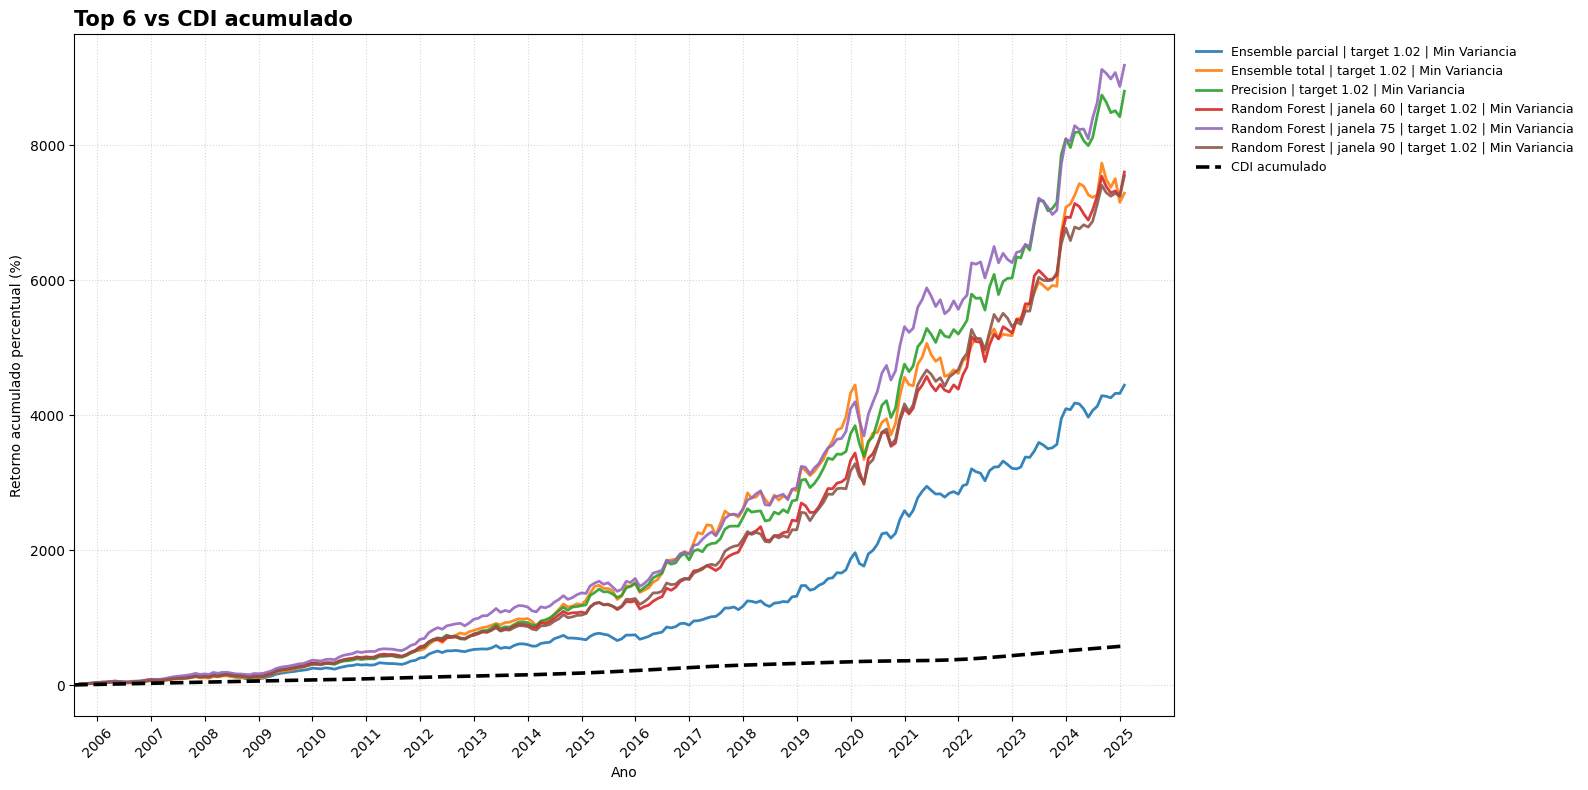

In [586]:
def plot_top6_vs_cdi(comparacao):
    import matplotlib.dates as mdates

    fig, ax = plt.subplots(figsize=(16, 8))

    data_min = comparacao["mes_referencia"].min()
    data_max = comparacao["mes_referencia"].max()
    limite_direito = pd.Timestamp(year=data_max.year, month=12, day=31)

    for serie_label, grupo in comparacao.groupby("serie_label"):
        grupo = grupo.sort_values("mes_referencia").copy()
        grupo["retorno_modelo_acumulado_percentual"] = ((1 + grupo["rentabilidade_mensal"]).cumprod() - 1) * 100

        ax.plot(
            grupo["mes_referencia"],
            grupo["retorno_modelo_acumulado_percentual"],
            linewidth=2.0,
            alpha=0.9,
            label=serie_label,
        )

    cdi_ref = comparacao.sort_values("mes_referencia").drop_duplicates(subset=["mes_referencia"]).copy()
    cdi_ref["retorno_cdi_acumulado_percentual"] = ((1 + cdi_ref["retorno_cdi_mensal"]).cumprod() - 1) * 100
    ax.plot(
        cdi_ref["mes_referencia"],
        cdi_ref["retorno_cdi_acumulado_percentual"],
        color="black",
        linestyle="--",
        linewidth=2.6,
        label="CDI acumulado",
    )

    ax.set_title("Top 6 vs CDI acumulado", loc="left", fontsize=15, fontweight="bold")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Retorno acumulado percentual (%)")
    ax.set_xlim(data_min, limite_direito)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.margins(x=0)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()


plot_top6_vs_cdi(COMPARACAO_TOP6_CDI)


O grafico `Top 6 vs CDI acumulado` compara a trajetoria de retorno acumulado das seis melhores series do ranking com a evolucao acumulada do CDI ao longo do mesmo intervalo temporal. Cada curva colorida representa uma das estrategias selecionadas, enquanto a linha tracejada em preto representa o benchmark do CDI. Como o eixo vertical esta em percentual acumulado, a leitura passa a mostrar quanto cada estrategia valorizou no periodo em relacao ao capital inicial.

A utilidade principal desse grafico e observar se as estrategias superam o benchmark conservador nao apenas no resultado final, mas tambem ao longo do caminho. Em alguns casos, uma serie pode terminar acima do CDI, mas passar longos trechos abaixo dele; em outros, a estrategia pode manter vantagem de forma mais consistente durante boa parte da amostra. Por isso, o grafico complementa a tabela-resumo: a tabela mostra o resultado consolidado, enquanto a figura evidencia a dinamica temporal dessa comparacao.

Outro ponto importante e que a comparacao respeita o mesmo periodo mensal utilizado nas series do top 6. Assim, a curva do CDI nao deve ser interpretada como um historico generico do indicador, mas sim como o desempenho acumulado do benchmark exatamente nos meses em que os modelos estao sendo avaliados. Isso torna a leitura mais justa e metodologicamente consistente para a analise comparativa.


In [587]:
TESTE_TOP6_CDI = testar_superacao_mensal_benchmark(COMPARACAO_TOP6_CDI, "retorno_cdi_mensal")

display(TESTE_TOP6_CDI[[
    "serie_label",
    "meses_comparados",
    "crescimento_medio_mensal_modelo_percentual",
    "crescimento_medio_mensal_benchmark_percentual",
    "diferencial_crescimento_medio_mensal_percentual",
    "p_valor_t",
]].sort_values(["p_valor_t", "diferencial_crescimento_medio_mensal_percentual"], ascending=[True, False]))

significativas_t = TESTE_TOP6_CDI[TESTE_TOP6_CDI["significativo_t_5pct"]]["serie_label"].tolist()

texto_cdi = f"""
**Teste de hipoteses para comparacao com o CDI**

Foi aplicado, para cada uma das seis estrategias, um teste unilateral sobre a diferenca entre as taxas de crescimento medio mensal composto do modelo e do CDI, a partir da transformacao `log(1 + retorno_mensal)`. A formulacao adotada foi: `H0`: o crescimento medio mensal do modelo e igual ou inferior ao crescimento medio mensal do CDI; `H1`: o crescimento medio mensal do modelo e superior ao crescimento medio mensal do CDI.

Ao nivel de 5%, {'as seguintes series apresentaram evidencia estatisticamente significativa de crescimento medio mensal superior ao CDI: ' + ', '.join(significativas_t) + '.' if significativas_t else 'nenhuma das series apresentou evidencia estatisticamente significativa de crescimento medio mensal superior ao CDI.'} Essa formulacao permite interpretar o teste em termos de capitalizacao composta, o que o torna mais aderente tanto a dinamica do capital acumulado quanto a leitura do grafico comparativo apresentado nesta secao.

Em termos substantivos, o resultado do teste ajuda a distinguir situacoes em que a estrategia termina o periodo acima do benchmark apenas por alguns episodios especificos daquelas em que o modelo sustenta uma taxa media de crescimento mensal superior ao CDI ao longo do horizonte analisado.
"""

display(Markdown(texto_cdi))

,serie_label,meses_comparados,crescimento_medio_mensal_modelo_percentual,crescimento_medio_mensal_benchmark_percentual,diferencial_crescimento_medio_mensal_percentual,p_valor_t
0,Random Forest | janela 75 | target 1.02 | Min ...,235,1.946921,0.817858,1.129063,0.000002
3,Random Forest | janela 90 | target 1.02 | Min ...,235,1.862687,0.817858,1.044828,0.000005
1,Precision | target 1.02 | Min Variancia,235,1.928627,0.817858,1.110769,0.000005
2,Random Forest | janela 60 | target 1.02 | Min ...,235,1.865903,0.817858,1.048045,0.000013
4,Ensemble total | target 1.02 | Min Variancia,235,1.847925,0.817858,1.030067,0.000134
5,Ensemble parcial | target 1.02 | Min Variancia,235,1.637430,0.817858,0.819571,0.000482



**Teste de hipoteses para comparacao com o CDI**

Foi aplicado, para cada uma das seis estrategias, um teste unilateral sobre a diferenca entre as taxas de crescimento medio mensal composto do modelo e do CDI, a partir da transformacao `log(1 + retorno_mensal)`. A formulacao adotada foi: `H0`: o crescimento medio mensal do modelo e igual ou inferior ao crescimento medio mensal do CDI; `H1`: o crescimento medio mensal do modelo e superior ao crescimento medio mensal do CDI.

Ao nivel de 5%, as seguintes series apresentaram evidencia estatisticamente significativa de crescimento medio mensal superior ao CDI: Random Forest | janela 75 | target 1.02 | Min Variancia, Precision | target 1.02 | Min Variancia, Random Forest | janela 60 | target 1.02 | Min Variancia, Random Forest | janela 90 | target 1.02 | Min Variancia, Ensemble total | target 1.02 | Min Variancia, Ensemble parcial | target 1.02 | Min Variancia. Essa formulacao permite interpretar o teste em termos de capitalizacao composta, o que o torna mais aderente tanto a dinamica do capital acumulado quanto a leitura do grafico comparativo apresentado nesta secao.

Em termos substantivos, o resultado do teste ajuda a distinguir situacoes em que a estrategia termina o periodo acima do benchmark apenas por alguns episodios especificos daquelas em que o modelo sustenta uma taxa media de crescimento mensal superior ao CDI ao longo do horizonte analisado.


## Comparacao com o Ibovespa

Nesta etapa, as 6 melhores series do ranking sao comparadas com o Ibovespa mensal como proxy para o mercado acionario brasileiro.

Observacoes importantes sobre o baseline:

- o arquivo original exportado do Yahoo Finance foi formatado e salvo em `data/estatisticas/baselines/ibovespa_mensal_formatado.csv`;
- a comparacao usa o fechamento mensal do indice;
- o retorno mensal do Ibovespa e calculado por `pct_change()` sobre o fechamento;
- este baseline funciona como uma proxy do mercado, mas nao representa um indice de retorno total com dividendos.

Com isso, a comparacao passa a responder:

- qual foi o retorno mensal do modelo;
- qual foi o retorno mensal do Ibovespa no mesmo mes;
- qual foi o excesso de retorno do modelo sobre essa proxy de mercado.

O benchmark de mercado utilizado nesta etapa e o Ibovespa mensal obtido a partir de serie exportada do Yahoo Finance e posteriormente formatada para uso no notebook. A comparacao considera o fechamento mensal do indice, e o retorno de cada mes e calculado pela variacao percentual entre fechamentos consecutivos. Dessa forma, o Ibovespa e empregado como uma proxy do comportamento do mercado acionario brasileiro ao longo do periodo analisado.

Cabe ressaltar, contudo, que essa serie nao corresponde a um indice de retorno total com reinvestimento de dividendos e demais proventos. Assim, sua utilizacao deve ser interpretada como uma aproximacao do desempenho agregado do mercado, adequada para fins comparativos, mas com a limitacao de nao incorporar integralmente o retorno distribuido pelas acoes que compoem o indice.


In [588]:
IBOVESPA_BASELINE_PATH = ROOT / "data" / "estatisticas" / "baselines" / "ibovespa_mensal_formatado.csv"


def carregar_ibovespa_mensal(path):
    df = pd.read_csv(path)
    df["mes_referencia"] = pd.to_datetime(df["mes_referencia"], errors="coerce")
    colunas_numericas = ["fechamento", "abertura", "maxima", "minima", "volume", "retorno_ibovespa_mensal"]
    for coluna in colunas_numericas:
        if coluna in df.columns:
            df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

    df = df.dropna(subset=["mes_referencia", "retorno_ibovespa_mensal"]).sort_values("mes_referencia").reset_index(drop=True)
    return df


def construir_comparacao_top6_ibovespa(series, top6_ids, ibovespa_mensal):
    linhas = []

    for serie_id in top6_ids:
        if serie_id not in series:
            continue

        info = series[serie_id]
        monthly = info["monthly"].copy()
        monthly = monthly[["mes_referencia", "rentabilidade_mensal"]].copy()
        monthly["serie_id"] = serie_id
        monthly["serie_label"] = info["serie_label"]
        monthly["grupo_label"] = info["grupo_label"]
        linhas.append(monthly)

    base = pd.concat(linhas, ignore_index=True)
    comparacao = base.merge(
        ibovespa_mensal[["mes_referencia", "retorno_ibovespa_mensal"]],
        on="mes_referencia",
        how="left",
    )
    comparacao = comparacao.dropna(subset=["rentabilidade_mensal", "retorno_ibovespa_mensal"])
    comparacao["excesso_retorno"] = comparacao["rentabilidade_mensal"] - comparacao["retorno_ibovespa_mensal"]
    comparacao["modelo_superou_ibovespa"] = comparacao["excesso_retorno"] > 0
    return comparacao.sort_values(["serie_label", "mes_referencia"]).reset_index(drop=True)


def resumir_comparacao_top6_ibovespa(comparacao):
    def retorno_acumulado(serie):
        serie = pd.to_numeric(serie, errors="coerce").dropna()
        if serie.empty:
            return np.nan
        return (1 + serie).prod() - 1

    resumo = (
        comparacao.groupby(["serie_id", "serie_label", "grupo_label"], dropna=False)
        .agg(
            retorno_modelo_acumulado=("rentabilidade_mensal", retorno_acumulado),
            retorno_ibovespa_acumulado=("retorno_ibovespa_mensal", retorno_acumulado),
            meses_comparados=("mes_referencia", "count"),
            meses_acima_ibovespa=("modelo_superou_ibovespa", "sum"),
        )
        .reset_index()
    )

    resumo["percentual_meses_acima_ibovespa"] = np.where(
        resumo["meses_comparados"] > 0,
        resumo["meses_acima_ibovespa"] / resumo["meses_comparados"] * 100,
        np.nan,
    )

    resumo["retorno_modelo_acumulado_percentual"] = resumo["retorno_modelo_acumulado"] * 100
    resumo["retorno_ibovespa_acumulado_percentual"] = resumo["retorno_ibovespa_acumulado"] * 100

    return resumo.sort_values("retorno_modelo_acumulado", ascending=False).reset_index(drop=True)


IBOVESPA_MENSAL = carregar_ibovespa_mensal(IBOVESPA_BASELINE_PATH)
COMPARACAO_TOP6_IBOVESPA = construir_comparacao_top6_ibovespa(SERIES, TOP6_SERIE_IDS, IBOVESPA_MENSAL)
RESUMO_TOP6_IBOVESPA = resumir_comparacao_top6_ibovespa(COMPARACAO_TOP6_IBOVESPA)

RESUMO_TOP6_IBOVESPA.to_csv(RESULTADOS_DIR / "resumo_top6_vs_ibovespa.csv", index=False)

RESUMO_TOP6_IBOVESPA[[
    "serie_label",
    "retorno_modelo_acumulado_percentual",
    "retorno_ibovespa_acumulado_percentual",
    "percentual_meses_acima_ibovespa",
]]


,serie_label,retorno_modelo_acumulado_percentual,retorno_ibovespa_acumulado_percentual,percentual_meses_acima_ibovespa
0,Random Forest | janela 75 | target 1.02 | Min ...,9187.892684,403.512834,58.723404
1,Precision | target 1.02 | Min Variancia,8804.322700,403.512834,57.446809
2,Random Forest | janela 60 | target 1.02 | Min ...,7605.085402,403.512834,60.425532
3,Random Forest | janela 90 | target 1.02 | Min ...,7548.120607,403.512834,55.744681
4,Ensemble total | target 1.02 | Min Variancia,7292.027095,403.512834,59.148936
5,Ensemble parcial | target 1.02 | Min Variancia,4445.829416,403.512834,54.893617


**Leitura das metricas do resumo**

- `retorno_modelo_acumulado_percentual`: retorno acumulado da estrategia ao longo do periodo analisado;
- `retorno_ibovespa_acumulado_percentual`: retorno acumulado do Ibovespa no mesmo intervalo mensal;
- `percentual_meses_acima_ibovespa`: percentual de meses em que a rentabilidade mensal do modelo foi maior que a rentabilidade mensal do Ibovespa.


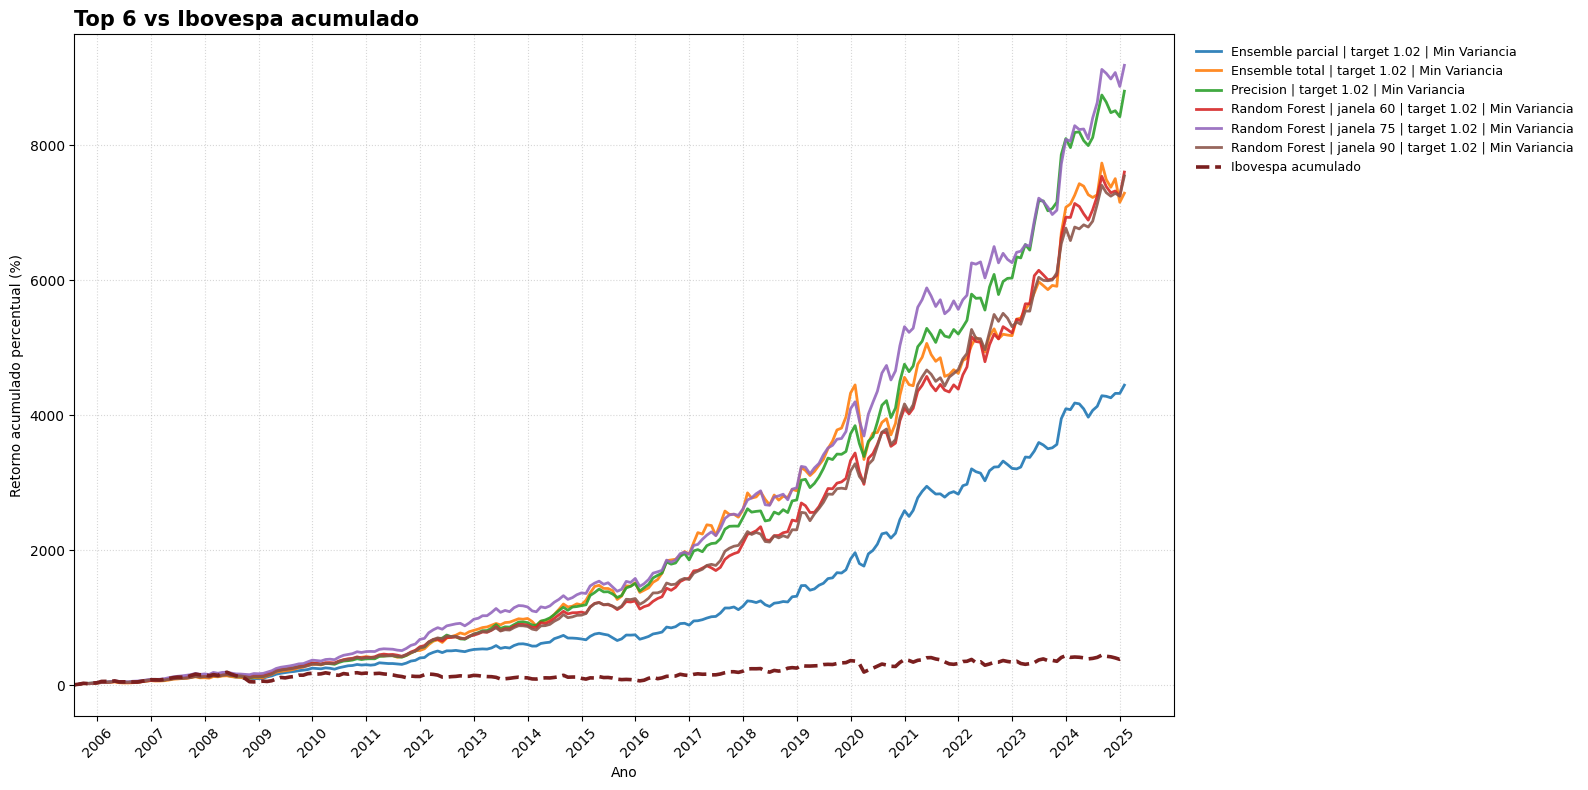

In [589]:
def plot_top6_vs_ibovespa(comparacao):
    import matplotlib.dates as mdates

    fig, ax = plt.subplots(figsize=(16, 8))

    data_min = comparacao["mes_referencia"].min()
    data_max = comparacao["mes_referencia"].max()
    limite_direito = pd.Timestamp(year=data_max.year, month=12, day=31)

    for serie_label, grupo in comparacao.groupby("serie_label"):
        grupo = grupo.sort_values("mes_referencia").copy()
        grupo["retorno_modelo_acumulado_percentual"] = ((1 + grupo["rentabilidade_mensal"]).cumprod() - 1) * 100

        ax.plot(
            grupo["mes_referencia"],
            grupo["retorno_modelo_acumulado_percentual"],
            linewidth=2.0,
            alpha=0.9,
            label=serie_label,
        )

    ibov_ref = comparacao.sort_values("mes_referencia").drop_duplicates(subset=["mes_referencia"]).copy()
    ibov_ref["retorno_ibovespa_acumulado_percentual"] = ((1 + ibov_ref["retorno_ibovespa_mensal"]).cumprod() - 1) * 100
    ax.plot(
        ibov_ref["mes_referencia"],
        ibov_ref["retorno_ibovespa_acumulado_percentual"],
        color="#7a1f1f",
        linestyle="--",
        linewidth=2.6,
        label="Ibovespa acumulado",
    )

    ax.set_title("Top 6 vs Ibovespa acumulado", loc="left", fontsize=15, fontweight="bold")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Retorno acumulado percentual (%)")
    ax.set_xlim(data_min, limite_direito)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.margins(x=0)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()


plot_top6_vs_ibovespa(COMPARACAO_TOP6_IBOVESPA)


O grafico `Top 6 vs Ibovespa acumulado` compara a trajetoria de retorno acumulado das seis melhores estrategias com a evolucao acumulada do Ibovespa no mesmo intervalo temporal. As curvas coloridas representam os modelos selecionados, enquanto a linha tracejada indica o comportamento do benchmark de mercado. Como o eixo vertical esta expresso em percentual acumulado, a figura permite visualizar quanto cada estrategia valorizou ao longo da amostra em relacao ao capital inicial.

Essa representacao e particularmente util para avaliar se o desempenho superior, quando existente, ocorreu de forma concentrada em poucos momentos ou se foi sustentado ao longo do tempo. Assim, o grafico complementa a tabela-resumo ao evidenciar a dinamica temporal da comparacao com o mercado acionario brasileiro, permitindo observar periodos de convergencia, superacao ou perda relativa em relacao ao Ibovespa.

Por fim, a leitura deve considerar que o benchmark utilizado e uma proxy baseada no fechamento mensal do indice. Portanto, a figura expressa a comparacao entre as estrategias e o comportamento agregado do mercado em termos de variacao do nivel do Ibovespa, e nao em termos de um indice de retorno total com reinvestimento de proventos.


In [590]:
TESTE_TOP6_IBOVESPA = testar_superacao_mensal_benchmark(COMPARACAO_TOP6_IBOVESPA, "retorno_ibovespa_mensal")

display(TESTE_TOP6_IBOVESPA[[
    "serie_label",
    "meses_comparados",
    "crescimento_medio_mensal_modelo_percentual",
    "crescimento_medio_mensal_benchmark_percentual",
    "diferencial_crescimento_medio_mensal_percentual",
    "p_valor_t",
]].sort_values(["p_valor_t", "diferencial_crescimento_medio_mensal_percentual"], ascending=[True, False]))

significativas_t = TESTE_TOP6_IBOVESPA[TESTE_TOP6_IBOVESPA["significativo_t_5pct"]]["serie_label"].tolist()

texto_ibov = f"""
**Teste de hipoteses para comparacao com o Ibovespa**

Foi aplicado, para cada uma das seis estrategias, um teste unilateral sobre a diferenca entre as taxas de crescimento medio mensal composto do modelo e do Ibovespa, a partir da transformacao `log(1 + retorno_mensal)`. A formulacao adotada foi: `H0`: o crescimento medio mensal do modelo e igual ou inferior ao crescimento medio mensal do Ibovespa; `H1`: o crescimento medio mensal do modelo e superior ao crescimento medio mensal do Ibovespa.

Ao nivel de 5%, {'as seguintes series apresentaram evidencia estatisticamente significativa de crescimento medio mensal superior ao Ibovespa: ' + ', '.join(significativas_t) + '.' if significativas_t else 'nenhuma das series apresentou evidencia estatisticamente significativa de crescimento medio mensal superior ao Ibovespa.'} Essa formulacao permite interpretar o teste em termos de capitalizacao composta, o que o torna mais aderente tanto a dinamica do capital acumulado quanto a leitura do grafico comparativo apresentado nesta secao.

Em termos substantivos, o resultado do teste ajuda a distinguir situacoes em que a estrategia termina o periodo acima do benchmark apenas por alguns episodios especificos daquelas em que o modelo sustenta uma taxa media de crescimento mensal superior ao mercado ao longo do horizonte analisado.
"""

display(Markdown(texto_ibov))

,serie_label,meses_comparados,crescimento_medio_mensal_modelo_percentual,crescimento_medio_mensal_benchmark_percentual,diferencial_crescimento_medio_mensal_percentual,p_valor_t
0,Random Forest | janela 75 | target 1.02 | Min ...,235,1.946921,0.690217,1.256704,0.000082
1,Precision | target 1.02 | Min Variancia,235,1.928627,0.690217,1.238409,0.000098
4,Ensemble total | target 1.02 | Min Variancia,235,1.847925,0.690217,1.157708,0.000151
2,Random Forest | janela 60 | target 1.02 | Min ...,235,1.865903,0.690217,1.175686,0.000176
3,Random Forest | janela 90 | target 1.02 | Min ...,235,1.862687,0.690217,1.172469,0.000194
5,Ensemble parcial | target 1.02 | Min Variancia,235,1.637430,0.690217,0.947212,0.002035



**Teste de hipoteses para comparacao com o Ibovespa**

Foi aplicado, para cada uma das seis estrategias, um teste unilateral sobre a diferenca entre as taxas de crescimento medio mensal composto do modelo e do Ibovespa, a partir da transformacao `log(1 + retorno_mensal)`. A formulacao adotada foi: `H0`: o crescimento medio mensal do modelo e igual ou inferior ao crescimento medio mensal do Ibovespa; `H1`: o crescimento medio mensal do modelo e superior ao crescimento medio mensal do Ibovespa.

Ao nivel de 5%, as seguintes series apresentaram evidencia estatisticamente significativa de crescimento medio mensal superior ao Ibovespa: Random Forest | janela 75 | target 1.02 | Min Variancia, Precision | target 1.02 | Min Variancia, Random Forest | janela 60 | target 1.02 | Min Variancia, Random Forest | janela 90 | target 1.02 | Min Variancia, Ensemble total | target 1.02 | Min Variancia, Ensemble parcial | target 1.02 | Min Variancia. Essa formulacao permite interpretar o teste em termos de capitalizacao composta, o que o torna mais aderente tanto a dinamica do capital acumulado quanto a leitura do grafico comparativo apresentado nesta secao.

Em termos substantivos, o resultado do teste ajuda a distinguir situacoes em que a estrategia termina o periodo acima do benchmark apenas por alguns episodios especificos daquelas em que o modelo sustenta uma taxa media de crescimento mensal superior ao mercado ao longo do horizonte analisado.


## Drawdown do Top 6 e das baselines


Nesta etapa, o top 6 e comparado com as baselines de CDI e Ibovespa sob a otica de drawdown mensal.

O drawdown mede a queda percentual em relacao ao pico acumulado anterior.

- `drawdown`: queda corrente em cada mes, sempre medida contra o maior valor acumulado ate aquele momento;
- `max_drawdown`: pior queda observada em toda a serie;
- `periodo do max_drawdown`: intervalo entre o pico anterior e o fundo dessa pior queda;
- `recuperacao`: primeiro mes em que a serie volta ao nivel do pico anterior, quando isso acontece.

In [591]:
def construir_base_drawdown(series, top6_ids, cdi_mensal, ibovespa_mensal):
    linhas = []

    for serie_id in top6_ids:
        if serie_id not in series:
            continue

        info = series[serie_id]
        monthly = info["monthly"][["mes_referencia", "rentabilidade_mensal"]].copy()
        monthly = monthly.dropna(subset=["rentabilidade_mensal"]).sort_values("mes_referencia")
        monthly["serie_label"] = info["serie_label"]
        monthly = monthly.rename(columns={"rentabilidade_mensal": "retorno_mensal"})
        linhas.append(monthly[["mes_referencia", "serie_label", "retorno_mensal"]])

    base_modelos = pd.concat(linhas, ignore_index=True)
    data_inicio = base_modelos["mes_referencia"].min()
    data_fim = base_modelos["mes_referencia"].max()

    cdi_base = cdi_mensal.copy()
    cdi_base = cdi_base[(cdi_base["mes_referencia"] >= data_inicio) & (cdi_base["mes_referencia"] <= data_fim)].copy()
    cdi_base["serie_label"] = "CDI"
    cdi_base = cdi_base.rename(columns={"retorno_cdi_mensal": "retorno_mensal"})

    ibov_base = ibovespa_mensal.copy()
    ibov_base = ibov_base[(ibov_base["mes_referencia"] >= data_inicio) & (ibov_base["mes_referencia"] <= data_fim)].copy()
    ibov_base["serie_label"] = "Ibovespa"
    ibov_base = ibov_base.rename(columns={"retorno_ibovespa_mensal": "retorno_mensal"})

    base = pd.concat([
        base_modelos,
        cdi_base[["mes_referencia", "serie_label", "retorno_mensal"]],
        ibov_base[["mes_referencia", "serie_label", "retorno_mensal"]],
    ], ignore_index=True)

    return base.sort_values(["serie_label", "mes_referencia"]).reset_index(drop=True)


def calcular_drawdown_series(base_drawdown):
    linhas = []
    resumo = []

    for serie_label, grupo in base_drawdown.groupby("serie_label"):
        grupo = grupo.sort_values("mes_referencia").copy().reset_index(drop=True)
        grupo["retorno_mensal"] = pd.to_numeric(grupo["retorno_mensal"], errors="coerce")
        grupo = grupo.dropna(subset=["retorno_mensal"]).reset_index(drop=True)

        grupo["indice_acumulado"] = (1 + grupo["retorno_mensal"]).cumprod()
        grupo["pico_acumulado"] = grupo["indice_acumulado"].cummax()
        grupo["drawdown"] = grupo["indice_acumulado"] / grupo["pico_acumulado"] - 1
        grupo["drawdown_percentual"] = grupo["drawdown"] * 100
        grupo["serie_label"] = serie_label
        linhas.append(grupo)

        if grupo.empty:
            continue

        idx_fundo = grupo["drawdown"].idxmin()
        fundo = grupo.loc[idx_fundo]
        valor_pico = fundo["pico_acumulado"]

        ate_fundo = grupo.loc[:idx_fundo].copy()
        candidatos_pico = ate_fundo.index[np.isclose(ate_fundo["indice_acumulado"], valor_pico)]
        idx_pico = int(candidatos_pico[-1]) if len(candidatos_pico) else 0
        pico = grupo.loc[idx_pico]

        apos_fundo = grupo.loc[idx_fundo + 1 :].copy()
        recuperacao = apos_fundo[apos_fundo["indice_acumulado"] >= valor_pico]
        data_recuperacao = recuperacao["mes_referencia"].iloc[0] if not recuperacao.empty else pd.NaT

        resumo.append({
            "serie_label": serie_label,
            "max_drawdown": fundo["drawdown"],
            "max_drawdown_percentual": fundo["drawdown_percentual"],
            "data_pico_previo": pico["mes_referencia"],
            "data_fundo": fundo["mes_referencia"],
            "data_recuperacao": data_recuperacao,
            "periodo_maior_drawdown": f"{pico['mes_referencia']:%Y-%m} a {fundo['mes_referencia']:%Y-%m}",
            "duracao_ate_fundo_meses": max((fundo["mes_referencia"].year - pico["mes_referencia"].year) * 12 + (fundo["mes_referencia"].month - pico["mes_referencia"].month), 0),
            "duracao_recuperacao_meses": (
                max((data_recuperacao.year - pico["mes_referencia"].year) * 12 + (data_recuperacao.month - pico["mes_referencia"].month), 0)
                if pd.notna(data_recuperacao)
                else np.nan
            ),
        })

    detalhado = pd.concat(linhas, ignore_index=True)
    resumo = pd.DataFrame(resumo).sort_values("max_drawdown", ascending=True).reset_index(drop=True)
    return detalhado, resumo


BASE_DRAWDOWN = construir_base_drawdown(SERIES, TOP6_SERIE_IDS, CDI_MENSAL, IBOVESPA_MENSAL)
DRAWDOWN_DETALHADO, RESUMO_DRAWDOWN = calcular_drawdown_series(BASE_DRAWDOWN)

RESUMO_DRAWDOWN.to_csv(RESULTADOS_DIR / "resumo_drawdown_top6_baselines.csv", index=False)

RESUMO_DRAWDOWN[[
    "serie_label",
    "max_drawdown_percentual",
    "data_pico_previo",
    "data_fundo",
    "data_recuperacao",
    "periodo_maior_drawdown",
    "duracao_ate_fundo_meses",
    "duracao_recuperacao_meses",
]]


,serie_label,max_drawdown_percentual,data_pico_previo,data_fundo,data_recuperacao,periodo_maior_drawdown,duracao_ate_fundo_meses,duracao_recuperacao_meses
0,Ibovespa,-49.587426,2008-05-31,2008-11-30,2017-09-30,2008-05 a 2008-11,6,112
1,Ensemble total | target 1.02 | Min Variancia,-24.316896,2020-01-31,2020-03-31,2020-12-31,2020-01 a 2020-03,2,11
2,Ensemble parcial | target 1.02 | Min Variancia,-23.973535,2008-05-31,2008-10-31,2009-04-30,2008-05 a 2008-10,5,11
3,Precision | target 1.02 | Min Variancia,-19.528865,2008-05-31,2008-10-31,2009-03-31,2008-05 a 2008-10,5,10
4,Random Forest | janela 90 | target 1.02 | Min ...,-16.884878,2008-05-31,2008-10-31,2009-03-31,2008-05 a 2008-10,5,10
5,Random Forest | janela 60 | target 1.02 | Min ...,-14.973570,2008-05-31,2008-10-31,2009-02-28,2008-05 a 2008-10,5,9
6,Random Forest | janela 75 | target 1.02 | Min ...,-12.290647,2008-05-31,2008-10-31,2009-02-28,2008-05 a 2008-10,5,9
7,CDI,0.000000,2005-07-31,2005-07-31,2005-08-31,2005-07 a 2005-07,0,1


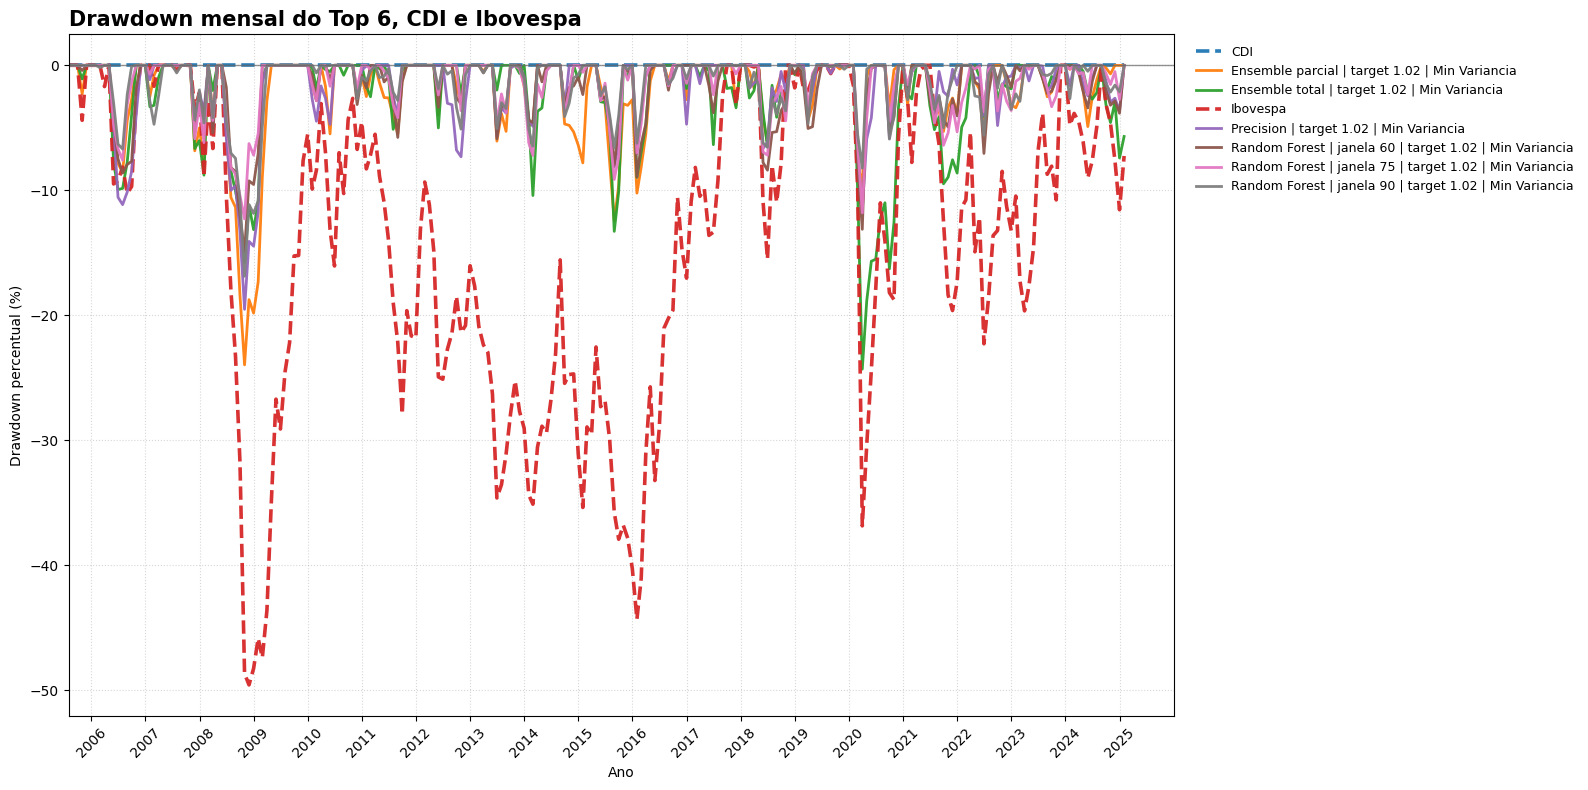

In [592]:
def plot_drawdown_top6_baselines(drawdown_detalhado):
    import matplotlib.dates as mdates

    fig, ax = plt.subplots(figsize=(16, 8))

    data_min = drawdown_detalhado["mes_referencia"].min()
    data_max = drawdown_detalhado["mes_referencia"].max()
    limite_direito = pd.Timestamp(year=data_max.year, month=12, day=31)

    for serie_label, grupo in drawdown_detalhado.groupby("serie_label"):
        grupo = grupo.sort_values("mes_referencia")
        estilo = {"linewidth": 2.6, "linestyle": "--"} if serie_label in ["CDI", "Ibovespa"] else {"linewidth": 2.0, "linestyle": "-"}
        ax.plot(
            grupo["mes_referencia"],
            grupo["drawdown_percentual"],
            alpha=0.95,
            label=serie_label,
            **estilo,
        )

    ax.axhline(0, color="#666666", linewidth=1.0, alpha=0.7)
    ax.set_title("Drawdown mensal do Top 6, CDI e Ibovespa", loc="left", fontsize=15, fontweight="bold")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Drawdown percentual (%)")
    ax.set_xlim(data_min, limite_direito)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.margins(x=0)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()


plot_drawdown_top6_baselines(DRAWDOWN_DETALHADO)


O grafico de drawdown mensal compara a intensidade das perdas relativas das estrategias do top 6 com as baselines de CDI e Ibovespa ao longo do tempo. Em cada ponto da serie, o drawdown indica o quanto a estrategia se encontra abaixo do seu pico acumulado anterior. Por essa razao, valores mais negativos representam quedas mais profundas, enquanto valores proximos de zero indicam momentos em que a serie esta no pico historico ou muito proxima dele.

A principal contribuicao da figura consiste em evidenciar o risco de percurso das estrategias, isto e, o tamanho das perdas enfrentadas entre um pico e a posterior recuperacao. Assim, duas series podem apresentar retornos acumulados finais elevados e, ainda assim, diferir substancialmente em termos de profundidade e persistencia das quedas ao longo do caminho. Sob essa perspectiva, o grafico complementa a analise de retorno ao permitir avaliar nao apenas quanto cada estrategia rendeu, mas tambem qual foi o custo de risco suportado para atingir esse resultado.

No caso das baselines, a comparacao permite observar se os modelos selecionados sofreram quedas mais severas ou mais brandas do que o CDI e o Ibovespa em episodios de estresse de mercado. O comportamento mais adverso do Ibovespa pode ser associado tanto a choques relevantes, como a crise de 2008 e o periodo de estresse em 2020, quanto ao fato de o benchmark utilizado refletir a variacao do nivel do indice, sem incorporar um retorno total com reinvestimento de dividendos. Isso contribui para uma recuperacao mais lenta dos picos anteriores e ajuda a explicar por que o indice pode permanecer por longos intervalos abaixo de seus maximos historicos. Em contraste, o CDI tende a exibir drawdown muito reduzido ou praticamente nulo, pois se trata de uma referencia de renda fixa com acumulacao mais regular e sem a mesma exposicao a oscilacoes abruptas tipicas do mercado acionário. Dessa forma, a leitura conjunta do grafico e da tabela `RESUMO_DRAWDOWN` oferece uma interpretacao mais completa da relacao entre desempenho e risco no periodo analisado.


## Vencedores mensais de classificacao


Esta etapa olha para os resultados binarios de classificacao dos sinais de compra e identifica, em cada mes,
quais configuracoes tiveram mais `verdadeiros positivos`.

Regra principal:

- `verdadeiro positivo`: caso em que `target_pred == 1` e `target_real == 1`.

Desempate entre configuracoes no mesmo mes:

1. maior numero de `verdadeiros positivos`;
2. maior `precision_mensal`;
3. maior numero de `sinais_compra`;
4. maior `retorno_medio_sinais`.

In [593]:
TRAIN_OUTPUTS_DIR = ROOT / "data" / "train" / "outputs"
ENSEMBLE_JANELAS_DIR = ROOT / "data" / "ensemble" / "2_tot_par"
ENSEMBLE_PREC_DIR = ROOT / "data" / "ensemble" / "4_melhor_precision_valor"


def carregar_predicoes_tecnicas():
    frames = []

    for path in sorted(TRAIN_OUTPUTS_DIR.glob("target_previsto_*.csv")):
        df = pd.read_csv(path)
        colunas_necessarias = {
            "ativo", "target", "janela", "tecnica", "data",
            "target_real", "target_pred", "resultado_real",
        }

        if not colunas_necessarias.issubset(df.columns):
            continue

        df = df[list(colunas_necessarias)].copy()
        df["data"] = pd.to_datetime(df["data"], errors="coerce")
        df["target"] = pd.to_numeric(df["target"], errors="coerce")
        df["janela"] = pd.to_numeric(df["janela"], errors="coerce")
        df["target_real"] = pd.to_numeric(df["target_real"], errors="coerce").fillna(0).astype(int)
        df["target_pred"] = pd.to_numeric(df["target_pred"], errors="coerce").fillna(0).astype(int)
        df["resultado_real"] = pd.to_numeric(df["resultado_real"], errors="coerce")
        df["tecnica"] = df["tecnica"].replace({"Random Forest": "RandomForest"})
        df = df.dropna(subset=["data", "target", "janela"])
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    base = pd.concat(frames, ignore_index=True)
    base["mes"] = base["data"].dt.to_period("M").dt.to_timestamp()
    base["configuracao"] = (
        base["tecnica"].astype(str)
        + " | janela "
        + base["janela"].astype(int).astype(str)
        + " | target "
        + base["target"].map(lambda v: f"{v:.3f}".rstrip("0").rstrip("."))
    )
    base["verdadeiro_positivo"] = ((base["target_pred"] == 1) & (base["target_real"] == 1)).astype(int)
    base["sinal_compra"] = (base["target_pred"] == 1).astype(int)
    return base


def resumir_tecnicas_por_mes(base):
    if base.empty:
        return pd.DataFrame()

    resumo = (
        base.groupby(["mes", "tecnica", "janela", "target", "configuracao"], dropna=False)
        .agg(
            verdadeiros_positivos=("verdadeiro_positivo", "sum"),
            sinais_compra=("sinal_compra", "sum"),
            retorno_medio_sinais=("resultado_real", lambda s: s[base.loc[s.index, "target_pred"] == 1].mean()),
            ativos_cobertos=("ativo", "nunique"),
            observacoes=("ativo", "size"),
        )
        .reset_index()
    )

    resumo["precision_mensal"] = np.where(
        resumo["sinais_compra"] > 0,
        resumo["verdadeiros_positivos"] / resumo["sinais_compra"],
        np.nan,
    )
    resumo["retorno_medio_sinais"] = resumo["retorno_medio_sinais"].fillna(0.0)
    return resumo.sort_values(["mes", "verdadeiros_positivos", "precision_mensal", "sinais_compra", "retorno_medio_sinais"], ascending=[True, False, False, False, False])


def selecionar_vencedores_mensais(resumo):
    if resumo.empty:
        return pd.DataFrame()

    vencedores = (
        resumo.sort_values(
            ["mes", "verdadeiros_positivos", "precision_mensal", "sinais_compra", "retorno_medio_sinais"],
            ascending=[True, False, False, False, False],
        )
        .groupby("mes", as_index=False)
        .first()
    )
    vencedores["mes_label"] = vencedores["mes"].dt.strftime("%Y-%m")
    return vencedores


def selecionar_vencedores_janela_por_tecnica_target(resumo):
    if resumo.empty:
        return pd.DataFrame()

    vencedores = (
        resumo.sort_values(
            ["mes", "tecnica", "target", "verdadeiros_positivos", "precision_mensal", "sinais_compra", "retorno_medio_sinais"],
            ascending=[True, True, True, False, False, False, False],
        )
        .groupby(["mes", "tecnica", "target"], as_index=False)
        .first()
    )
    vencedores["mes_label"] = vencedores["mes"].dt.strftime("%Y-%m")
    return vencedores


def carregar_base_ensemble():
    frames = []

    for path_ens in sorted(ENSEMBLE_JANELAS_DIR.glob("*_ensemble_jan_tot_e_parcial.csv")):
        ativo = path_ens.name.replace("_ensemble_jan_tot_e_parcial.csv", "")
        path_prec = ENSEMBLE_PREC_DIR / f"{ativo}_melhor_precision_valor.csv"

        if not path_prec.exists():
            continue

        df_ens = pd.read_csv(path_ens)
        df_prec = pd.read_csv(path_prec)

        merge_cols = ["ativo", "target", "data"]
        cols_ens = ["ativo", "target", "data", "target_real", "resultado_real", "esmble_jan_tot", "esmble_jan_par"]
        cols_prec = ["ativo", "target", "data", "concordancia_valor"]

        if not set(cols_ens).issubset(df_ens.columns) or not set(cols_prec).issubset(df_prec.columns):
            continue

        base = df_ens[cols_ens].merge(
            df_prec[cols_prec].rename(columns={"concordancia_valor": "in_precision"}),
            on=merge_cols,
            how="inner",
        )

        base["data"] = pd.to_datetime(base["data"], errors="coerce")
        base["target"] = pd.to_numeric(base["target"], errors="coerce")
        base["target_real"] = pd.to_numeric(base["target_real"], errors="coerce").fillna(0).astype(int)
        base["resultado_real"] = pd.to_numeric(base["resultado_real"], errors="coerce")
        base["mes"] = base["data"].dt.to_period("M").dt.to_timestamp()
        frames.append(base)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


def resumir_ensemble_por_mes(base):
    if base.empty:
        return pd.DataFrame()

    long = base.melt(
        id_vars=["ativo", "target", "data", "mes", "target_real", "resultado_real"],
        value_vars=["esmble_jan_tot", "esmble_jan_par", "in_precision"],
        var_name="ensemble",
        value_name="target_pred",
    )

    long["target_pred"] = pd.to_numeric(long["target_pred"], errors="coerce").fillna(0).astype(int)
    long["verdadeiro_positivo"] = ((long["target_pred"] == 1) & (long["target_real"] == 1)).astype(int)
    long["sinal_compra"] = (long["target_pred"] == 1).astype(int)

    resumo = (
        long.groupby(["mes", "ensemble"], dropna=False)
        .agg(
            verdadeiros_positivos=("verdadeiro_positivo", "sum"),
            sinais_compra=("sinal_compra", "sum"),
            retorno_medio_sinais=("resultado_real", lambda s: s[long.loc[s.index, "target_pred"] == 1].mean()),
            ativos_cobertos=("ativo", "nunique"),
            observacoes=("ativo", "size"),
        )
        .reset_index()
    )

    resumo["precision_mensal"] = np.where(
        resumo["sinais_compra"] > 0,
        resumo["verdadeiros_positivos"] / resumo["sinais_compra"],
        np.nan,
    )
    resumo["retorno_medio_sinais"] = resumo["retorno_medio_sinais"].fillna(0.0)
    resumo["ensemble_label"] = resumo["ensemble"].map(ENSEMBLE_TECNICAS_LABEL)
    return resumo.sort_values(["mes", "verdadeiros_positivos", "precision_mensal", "sinais_compra", "retorno_medio_sinais"], ascending=[True, False, False, False, False])


def selecionar_melhor_ensemble_mensal(resumo):
    if resumo.empty:
        return pd.DataFrame()

    vencedores = (
        resumo.sort_values(
            ["mes", "verdadeiros_positivos", "precision_mensal", "sinais_compra", "retorno_medio_sinais"],
            ascending=[True, False, False, False, False],
        )
        .groupby("mes", as_index=False)
        .first()
    )
    vencedores["mes_label"] = vencedores["mes"].dt.strftime("%Y-%m")
    return vencedores


def selecionar_melhor_ensemble_por_target_mensal(base):
    if base.empty:
        return pd.DataFrame()

    long = base.melt(
        id_vars=["ativo", "target", "data", "mes", "target_real", "resultado_real"],
        value_vars=["esmble_jan_tot", "esmble_jan_par", "in_precision"],
        var_name="ensemble",
        value_name="target_pred",
    )

    long["target_pred"] = pd.to_numeric(long["target_pred"], errors="coerce").fillna(0).astype(int)
    long["verdadeiro_positivo"] = ((long["target_pred"] == 1) & (long["target_real"] == 1)).astype(int)
    long["sinal_compra"] = (long["target_pred"] == 1).astype(int)

    resumo = (
        long.groupby(["mes", "target", "ensemble"], dropna=False)
        .agg(
            verdadeiros_positivos=("verdadeiro_positivo", "sum"),
            sinais_compra=("sinal_compra", "sum"),
            retorno_medio_sinais=("resultado_real", lambda s: s[long.loc[s.index, "target_pred"] == 1].mean()),
        )
        .reset_index()
    )

    resumo["precision_mensal"] = np.where(
        resumo["sinais_compra"] > 0,
        resumo["verdadeiros_positivos"] / resumo["sinais_compra"],
        np.nan,
    )
    resumo["retorno_medio_sinais"] = resumo["retorno_medio_sinais"].fillna(0.0)
    resumo["ensemble_label"] = resumo["ensemble"].map(ENSEMBLE_TECNICAS_LABEL)

    vencedores = (
        resumo.sort_values(
            ["mes", "target", "verdadeiros_positivos", "precision_mensal", "sinais_compra", "retorno_medio_sinais"],
            ascending=[True, True, False, False, False, False],
        )
        .groupby(["mes", "target"], as_index=False)
        .first()
    )
    vencedores["mes_label"] = vencedores["mes"].dt.strftime("%Y-%m")
    return vencedores


def resumir_target_retorno_por_mes(base):
    if base.empty:
        return pd.DataFrame()

    resumo = (
        base.groupby(["mes", "target"], dropna=False)
        .agg(
            retorno_medio_sinais=("resultado_real", lambda s: s[base.loc[s.index, "target_pred"] == 1].mean()),
            verdadeiros_positivos=("verdadeiro_positivo", "sum"),
            sinais_compra=("sinal_compra", "sum"),
        )
        .reset_index()
    )

    resumo["retorno_medio_sinais"] = resumo["retorno_medio_sinais"].fillna(0.0)
    resumo["target_label"] = resumo["target"].map(lambda v: f"{v:.3f}".rstrip("0").rstrip("."))
    return resumo.sort_values(["mes", "retorno_medio_sinais", "verdadeiros_positivos", "sinais_compra"], ascending=[True, False, False, False])


def selecionar_target_melhor_retorno_mensal(resumo):
    if resumo.empty:
        return pd.DataFrame()

    vencedores = (
        resumo.sort_values(
            ["mes", "retorno_medio_sinais", "verdadeiros_positivos", "sinais_compra"],
            ascending=[True, False, False, False],
        )
        .groupby("mes", as_index=False)
        .first()
    )
    vencedores["mes_label"] = vencedores["mes"].dt.strftime("%Y-%m")
    return vencedores


def selecionar_target_retorno_por_tecnica_janela(base):
    if base.empty:
        return pd.DataFrame()

    resumo = (
        base.groupby(["mes", "tecnica", "janela", "target"], dropna=False)
        .agg(
            retorno_medio_sinais=("resultado_real", lambda s: s[base.loc[s.index, "target_pred"] == 1].mean()),
            verdadeiros_positivos=("verdadeiro_positivo", "sum"),
            sinais_compra=("sinal_compra", "sum"),
        )
        .reset_index()
    )

    resumo["retorno_medio_sinais"] = resumo["retorno_medio_sinais"].fillna(0.0)
    resumo["target_label"] = resumo["target"].map(lambda v: f"{v:.3f}".rstrip("0").rstrip("."))

    vencedores = (
        resumo.sort_values(
            ["mes", "tecnica", "janela", "retorno_medio_sinais", "verdadeiros_positivos", "sinais_compra"],
            ascending=[True, True, True, False, False, False],
        )
        .groupby(["mes", "tecnica", "janela"], as_index=False)
        .first()
    )
    vencedores["mes_label"] = vencedores["mes"].dt.strftime("%Y-%m")
    return vencedores


BASE_TECNICAS_MENSAL = carregar_predicoes_tecnicas()
RANKING_CONFIG_MENSAL = resumir_tecnicas_por_mes(BASE_TECNICAS_MENSAL)
VENCEDORES_CONFIG_MENSAL = selecionar_vencedores_mensais(RANKING_CONFIG_MENSAL)
VENCEDORES_JANELA_TECNICA_TARGET = selecionar_vencedores_janela_por_tecnica_target(RANKING_CONFIG_MENSAL)

BASE_ENSEMBLE_MENSAL = carregar_base_ensemble()
RANKING_ENSEMBLE_MENSAL = resumir_ensemble_por_mes(BASE_ENSEMBLE_MENSAL)
VENCEDORES_ENSEMBLE_MENSAL = selecionar_melhor_ensemble_mensal(RANKING_ENSEMBLE_MENSAL)
VENCEDORES_ENSEMBLE_TARGET_MENSAL = selecionar_melhor_ensemble_por_target_mensal(BASE_ENSEMBLE_MENSAL)

RANKING_TARGET_RETORNO_MENSAL = resumir_target_retorno_por_mes(BASE_TECNICAS_MENSAL)
VENCEDORES_TARGET_RETORNO_MENSAL = selecionar_target_melhor_retorno_mensal(RANKING_TARGET_RETORNO_MENSAL)
VENCEDORES_TARGET_TECNICA_JANELA_MENSAL = selecionar_target_retorno_por_tecnica_janela(BASE_TECNICAS_MENSAL)


VENCEDORES_CONFIG_MENSAL.head()

,mes,tecnica,janela,target,configuracao,verdadeiros_positivos,sinais_compra,retorno_medio_sinais,ativos_cobertos,observacoes,precision_mensal,mes_label
0,2005-04-01,SVC,60,1.01,SVC | janela 60 | target 1.01,192,248,-0.001768,51,255,0.774194,2005-04
1,2005-05-01,SVC,60,1.01,SVC | janela 60 | target 1.01,870,1067,-0.000253,51,1071,0.815370,2005-05
2,2005-06-01,SVC,75,1.01,SVC | janela 75 | target 1.01,834,1113,-0.005242,51,1122,0.749326,2005-06
3,2005-07-01,SVC,90,1.01,SVC | janela 90 | target 1.01,880,1066,0.000533,51,1071,0.825516,2005-07
4,2005-08-01,SVC,75,1.01,SVC | janela 75 | target 1.01,1016,1172,0.004386,51,1173,0.866894,2005-08


**Leitura da tabela de vencedores mensais**

- `verdadeiros_positivos`: quantidade de sinais de compra corretos no mes.
- `sinais_compra`: quantidade total de compras previstas no mes.
- `precision_mensal`: `verdadeiros_positivos / sinais_compra`.
- `retorno_medio_sinais`: media de `resultado_real` nos casos em que houve sinal de compra.

A ordenacao do ranking mensal considera, primeiro, o numero de `verdadeiros_positivos` e, em seguida, os criterios de desempate. Assim, a tabela funciona como um apoio para identificar a configuracao vencedora de cada mes e para interpretar os graficos de janelas e targets vencedores ao longo do tempo.


In [594]:
VENCEDORES_CONFIG_MENSAL[
    [
        "mes",
        "tecnica",
        "janela",
        "target",
        "verdadeiros_positivos",
        "sinais_compra",
        "precision_mensal"
    ]
].head(15)

,mes,tecnica,janela,target,verdadeiros_positivos,sinais_compra,precision_mensal
0,2005-04-01,SVC,60,1.01,192,248,0.774194
1,2005-05-01,SVC,60,1.01,870,1067,0.815370
2,2005-06-01,SVC,75,1.01,834,1113,0.749326
3,2005-07-01,SVC,90,1.01,880,1066,0.825516
4,2005-08-01,SVC,75,1.01,1016,1172,0.866894
5,2005-09-01,SVC,90,1.01,915,1069,0.855940
6,2005-10-01,SVC,90,1.01,842,1020,0.825490
7,2005-11-01,SVC,60,1.01,812,1008,0.805556
8,2005-12-01,SVC,60,1.01,861,1090,0.789908
9,2006-01-01,SVC,60,1.01,951,1142,0.832750


In [595]:
def plot_janelas_vencedoras(vencedores):
    base = vencedores.copy()
    base["janela"] = base["janela"].astype(int)

    labels_janelas = {60: "Janela 60", 75: "Janela 75", 90: "Janela 90"}
    cores_janelas = {60: "#0f4c81", 75: "#32845d", 90: "#c05621"}

    contagem = (
        base["janela"]
        .value_counts()
        .reindex([60, 75, 90], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.pie(
        contagem.values,
        labels=[labels_janelas[j] for j in contagem.index],
        colors=[cores_janelas[j] for j in contagem.index],
        autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",
        startangle=90,
        counterclock=False,
        wedgeprops={"linewidth": 1.2, "edgecolor": "white"},
        textprops={"fontsize": 10},
    )
    ax.set_title(
        "Proporcao das janelas vencedoras no periodo",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )
    plt.show()


def plot_janelas_por_tecnica_target(vencedores):
    base = vencedores.copy()
    base["ano"] = base["mes"].dt.year
    base["mes_num"] = base["mes"].dt.month
    base["janela"] = base["janela"].astype(int)
    base["target_label"] = base["target"].map(lambda v: f"{v:.3f}".rstrip("0").rstrip("."))

    mapa_janelas = {60: 0, 75: 1, 90: 2}
    labels_janelas = {60: "Janela 60", 75: "Janela 75", 90: "Janela 90"}
    cores_janelas = ["#0f4c81", "#32845d", "#c05621"]

    cmap = LinearSegmentedColormap.from_list(
        "janelas_vencedoras_tecnica_target",
        cores_janelas,
        N=3,
    )

    fig, axes = plt.subplots(len(FAMILIAS), len(TARGETS), figsize=(18, 10), sharex=True, sharey=True)
    fig.subplots_adjust(top=0.90, bottom=0.10, wspace=0.08, hspace=0.20)
    last_image = None

    for i, familia in enumerate(FAMILIAS):
        for j, target in enumerate(TARGETS):
            ax = axes[i, j]
            fatia = base[(base["tecnica"] == familia) & (base["target_label"] == TARGETS_LABEL[target])]

            matriz = (
                fatia.assign(codigo_janela=fatia["janela"].map(mapa_janelas))
                .pivot(index="ano", columns="mes_num", values="codigo_janela")
                .reindex(columns=list(range(1, 13)))
                .sort_index(ascending=False)
            )

            last_image = ax.imshow(
                np.ma.masked_invalid(matriz.to_numpy(dtype=float)),
                aspect="auto",
                cmap=cmap,
                vmin=-0.5,
                vmax=2.5,
            )

            ax.set_title(
                f"{FAMILIAS_LABEL[familia]} | target {TARGETS_LABEL[target]}",
                loc="left",
                fontsize=10,
                fontweight="bold",
            )
            ax.set_xticks(range(12))
            ax.set_xticklabels([MESES_PT[m] for m in range(1, 13)], rotation=0)
            ax.set_yticks(range(len(matriz.index)))
            ax.set_yticklabels(matriz.index.astype(str))

            for spine in ax.spines.values():
                spine.set_visible(False)

            ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(matriz.index), 1), minor=True)
            ax.grid(which="minor", color="white", linestyle="-", linewidth=1.1)
            ax.tick_params(which="minor", bottom=False, left=False)

    fig.suptitle("Melhor janela por tecnica + target em cada mes", fontsize=15, fontweight="bold")
    fig.supxlabel("Mes")
    fig.supylabel("Ano")
    cbar = fig.colorbar(last_image, ax=axes, shrink=0.82, pad=0.02)
    cbar.set_ticks([0, 1, 2])
    cbar.set_ticklabels([labels_janelas[60], labels_janelas[75], labels_janelas[90]])
    cbar.ax.set_ylabel("Janela vencedora")
    plt.show()


def plot_target_maior_retorno(vencedores):
    rotulos_target = {"1.01": "1%", "1.015": "1,5%", "1.02": "2%"}
    ordem = sorted(vencedores["target_label"].dropna().unique(), key=lambda x: float(x))
    cores = {
        "1.01": "#7c3aed",
        "1.015": "#db2777",
        "1.02": "#ea580c",
    }

    contagem = (
        vencedores["target_label"]
        .value_counts()
        .reindex(ordem, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.pie(
        contagem.values,
        labels=[rotulos_target.get(label, label) for label in contagem.index],
        colors=[cores.get(label, "#6b7280") for label in contagem.index],
        autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",
        startangle=90,
        counterclock=False,
        wedgeprops={"linewidth": 1.2, "edgecolor": "white"},
        textprops={"fontsize": 10},
    )
    ax.set_title(
        "Proporcao dos targets vencedores no periodo",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )
    plt.show()


def plot_target_por_tecnica_janela(vencedores):
    rotulos_target = {"1.01": "1%", "1.015": "1,5%", "1.02": "2%"}
    ordem_targets = [rotulos_target[TARGETS_LABEL[t]] for t in TARGETS]
    mapa = {nome: i for i, nome in enumerate(ordem_targets)}
    cores = ["#7c3aed", "#db2777", "#ea580c"]
    cmap = LinearSegmentedColormap.from_list("target_por_tecnica_janela", cores, N=3)

    fig, axes = plt.subplots(len(FAMILIAS), len(JANELAS), figsize=(18, 10), sharex=True, sharey=True)
    fig.subplots_adjust(top=0.90, bottom=0.10, wspace=0.08, hspace=0.20)
    last_image = None

    for i, familia in enumerate(FAMILIAS):
        for j, janela in enumerate(JANELAS):
            ax = axes[i, j]
            fatia = vencedores[
                (vencedores["tecnica"] == familia)
                & (vencedores["janela"].astype(int) == int(janela))
            ]

            matriz = (
                fatia.assign(codigo_target=fatia["target_label"].map(rotulos_target).map(mapa))
                .assign(ano=lambda d: d["mes"].dt.year, mes_num=lambda d: d["mes"].dt.month)
                .pivot(index="ano", columns="mes_num", values="codigo_target")
                .reindex(columns=list(range(1, 13)))
                .sort_index(ascending=False)
            )

            last_image = ax.imshow(
                np.ma.masked_invalid(matriz.to_numpy(dtype=float)),
                aspect="auto",
                cmap=cmap,
                vmin=-0.5,
                vmax=2.5,
            )

            ax.set_title(
                f"{FAMILIAS_LABEL[familia]} | janela {janela}",
                loc="left",
                fontsize=10,
                fontweight="bold",
            )
            ax.set_xticks(range(12))
            ax.set_xticklabels([MESES_PT[m] for m in range(1, 13)], rotation=0)
            ax.set_yticks(range(len(matriz.index)))
            ax.set_yticklabels(matriz.index.astype(str))

            for spine in ax.spines.values():
                spine.set_visible(False)

            ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(matriz.index), 1), minor=True)
            ax.grid(which="minor", color="white", linestyle="-", linewidth=1.1)
            ax.tick_params(which="minor", bottom=False, left=False)

    fig.suptitle("Target de maior retorno por tecnica + janela em cada mes", fontsize=15, fontweight="bold")
    fig.supxlabel("Mes")
    fig.supylabel("Ano")
    cbar = fig.colorbar(last_image, ax=axes, shrink=0.82, pad=0.02)
    cbar.set_ticks([0, 1, 2])
    cbar.set_ticklabels(ordem_targets)
    cbar.ax.set_ylabel("Target vencedor")
    plt.show()


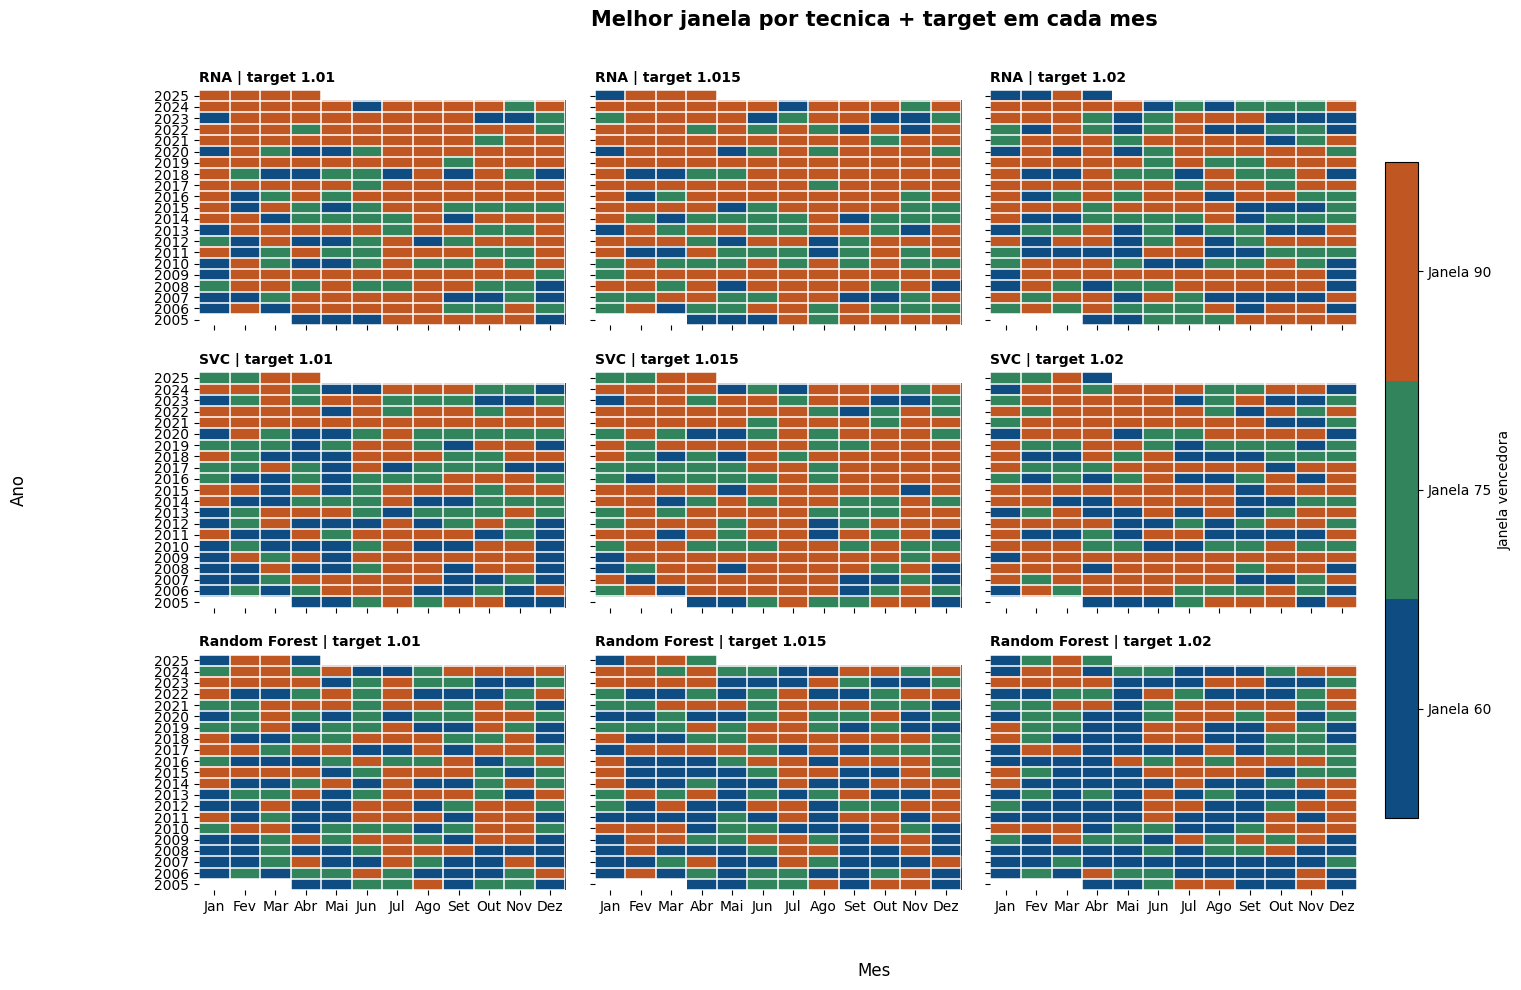

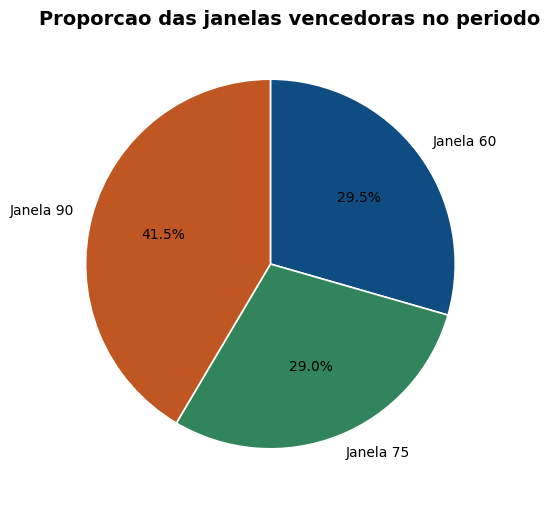

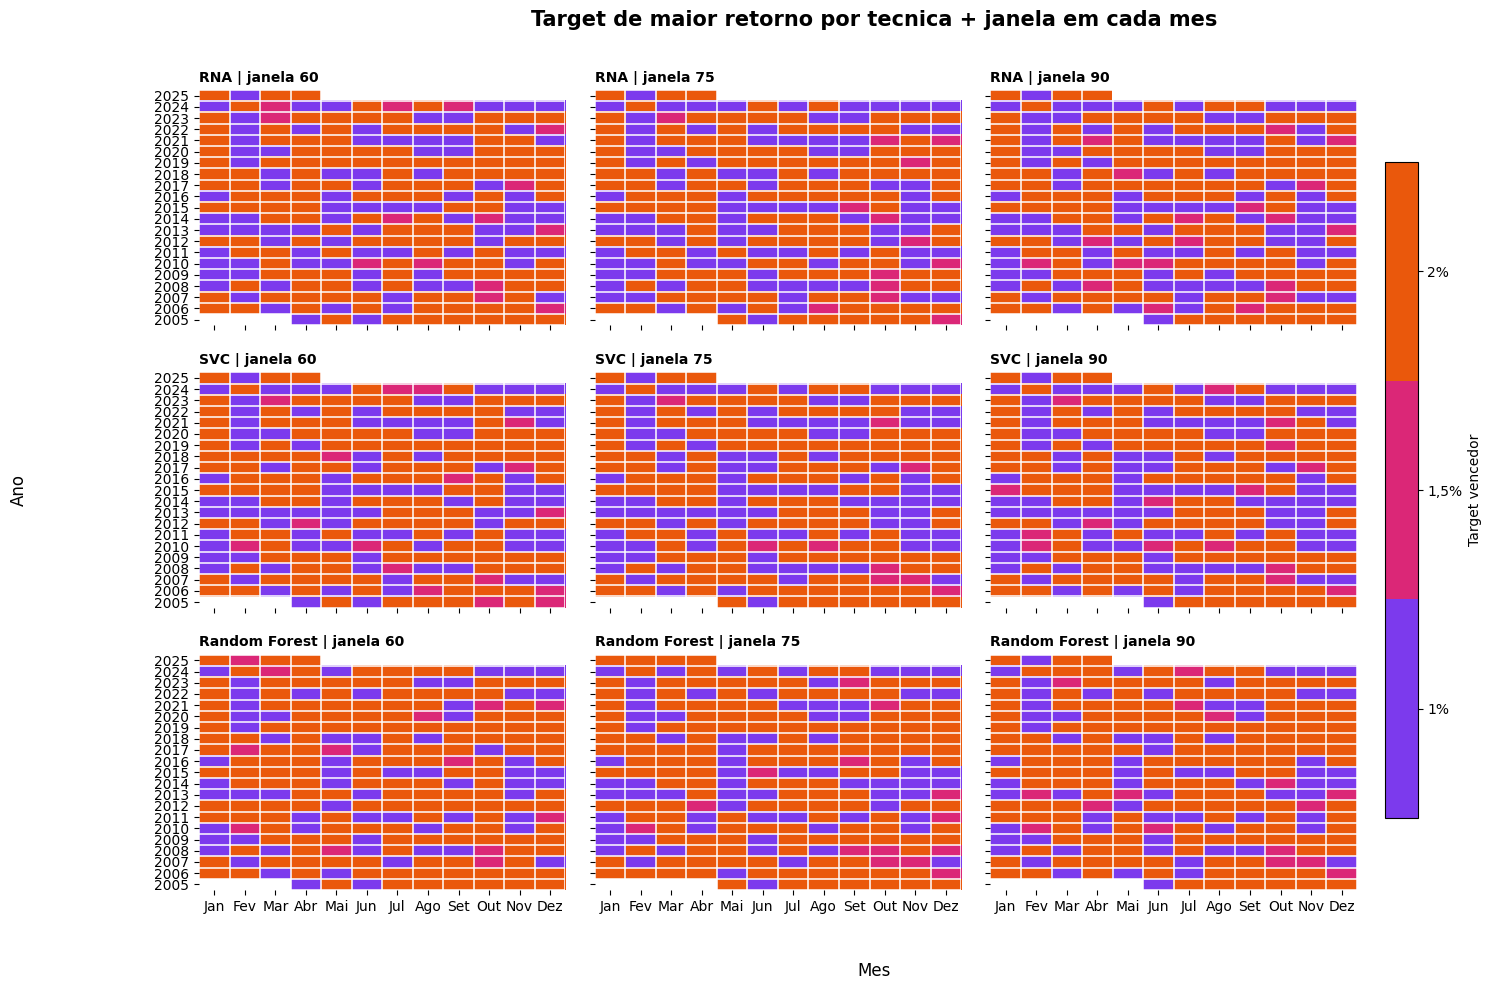

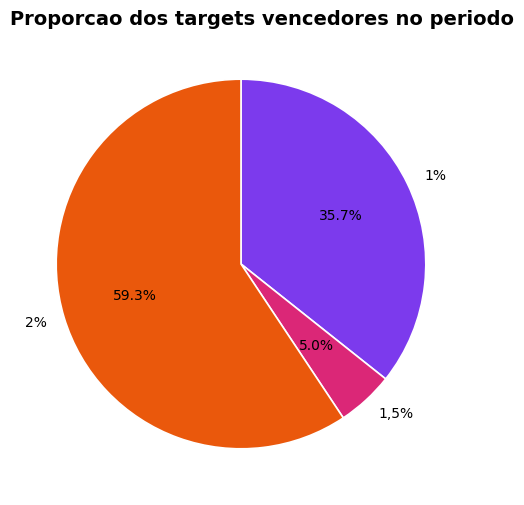

In [596]:
plot_janelas_por_tecnica_target(VENCEDORES_JANELA_TECNICA_TARGET)
plot_janelas_vencedoras(VENCEDORES_CONFIG_MENSAL)
plot_target_por_tecnica_janela(VENCEDORES_TARGET_TECNICA_JANELA_MENSAL)
plot_target_maior_retorno(VENCEDORES_TARGET_RETORNO_MENSAL)

**Leitura dos graficos de vencedores mensais**

Os dois blocos desta secao usam criterios diferentes:

- `melhor janela`: identifica a janela que obteve mais acertos de classificacao no mes, com foco em `verdadeiros_positivos`;
- `target de maior retorno`: identifica o target que entregou maior `retorno_medio_sinais` no mes.

Como interpretar:

- no heatmap de `melhor janela por tecnica + target`, cada quadrado mostra qual janela venceu naquele recorte mensal;
- na pizza de `janelas vencedoras`, vemos a proporcao acumulada de vitórias de cada janela ao longo de todo o periodo;
- no heatmap de `target por tecnica + janela`, cada quadrado mostra qual target entregou o maior retorno medio naquele recorte mensal;
- na pizza de `targets vencedores`, vemos a proporcao acumulada de vitórias de cada target ao longo do periodo.

In [597]:
CONTAGEM_JANELAS_VENCEDORAS = (
    VENCEDORES_CONFIG_MENSAL["janela"].astype(int).value_counts().reindex([60, 75, 90], fill_value=0)
)
TESTE_JANELAS_VENCEDORAS, ESTATISTICA_QUI2_JANELAS, P_VALOR_QUI2_JANELAS = testar_distribuicao_uniforme(
    CONTAGEM_JANELAS_VENCEDORAS,
    labels=["Janela 60", "Janela 75", "Janela 90"],
)

base_targets_vencedores = VENCEDORES_TARGET_RETORNO_MENSAL.copy()
if "target_label" not in base_targets_vencedores.columns:
    base_targets_vencedores["target_label"] = base_targets_vencedores["target"].map(lambda v: f"{v:.3f}".rstrip("0").rstrip("."))

rotulos_target = {"1.01": "1%", "1.015": "1,5%", "1.02": "2%"}
CONTAGEM_TARGETS_VENCEDORES = (
    base_targets_vencedores["target_label"].map(rotulos_target).value_counts().reindex(["1%", "1,5%", "2%"], fill_value=0)
)
TESTE_TARGETS_VENCEDORES, ESTATISTICA_QUI2_TARGETS, P_VALOR_QUI2_TARGETS = testar_distribuicao_uniforme(
    CONTAGEM_TARGETS_VENCEDORES,
    labels=["1%", "1,5%", "2%"],
)

print("Teste de distribuicao das janelas vencedoras")
display(TESTE_JANELAS_VENCEDORAS)
print("Teste de distribuicao dos targets vencedores")
display(TESTE_TARGETS_VENCEDORES)

RESUMO_TESTES_VENCEDORES = pd.DataFrame([
    {
        "analise": "Janelas vencedoras",
        "hipotese_nula": "distribuicao uniforme entre as tres janelas",
        "teste": "Qui-quadrado de aderencia",
        "estatistica": ESTATISTICA_QUI2_JANELAS,
        "p_valor": P_VALOR_QUI2_JANELAS,
        "significativo_5pct": pd.notna(P_VALOR_QUI2_JANELAS) and P_VALOR_QUI2_JANELAS < 0.05,
    },
    {
        "analise": "Targets vencedores",
        "hipotese_nula": "distribuicao uniforme entre os tres targets",
        "teste": "Qui-quadrado de aderencia",
        "estatistica": ESTATISTICA_QUI2_TARGETS,
        "p_valor": P_VALOR_QUI2_TARGETS,
        "significativo_5pct": pd.notna(P_VALOR_QUI2_TARGETS) and P_VALOR_QUI2_TARGETS < 0.05,
    },
])

RESUMO_TESTES_VENCEDORES_EXIBICAO = RESUMO_TESTES_VENCEDORES.copy()
RESUMO_TESTES_VENCEDORES_EXIBICAO["estatistica"] = RESUMO_TESTES_VENCEDORES_EXIBICAO["estatistica"].map(lambda v: round(v, 4) if pd.notna(v) else np.nan)
RESUMO_TESTES_VENCEDORES_EXIBICAO["p_valor"] = RESUMO_TESTES_VENCEDORES_EXIBICAO["p_valor"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "NA")
display(RESUMO_TESTES_VENCEDORES_EXIBICAO)

significativo_janelas = pd.notna(P_VALOR_QUI2_JANELAS) and P_VALOR_QUI2_JANELAS < 0.05
significativo_targets = pd.notna(P_VALOR_QUI2_TARGETS) and P_VALOR_QUI2_TARGETS < 0.05
janela_dominante = TESTE_JANELAS_VENCEDORAS.sort_values("observado", ascending=False).iloc[0]["categoria"]
target_dominante = TESTE_TARGETS_VENCEDORES.sort_values("observado", ascending=False).iloc[0]["categoria"]

texto_vencedores = f"""
**Teste de hipoteses para a distribuicao dos vencedores mensais**

Foram aplicados testes qui-quadrado de aderencia para verificar se a distribuicao observada dos vencedores mensais pode ser considerada uniforme entre as tres janelas candidatas e, separadamente, entre os tres targets avaliados. Em ambos os casos, a hipotese nula assume que cada categoria teria a mesma frequencia esperada de vitórias ao longo do periodo, enquanto a hipotese alternativa assume concentracao de vitórias em categorias especificas.

No caso das janelas, obteve-se estatistica qui-quadrado igual a `{ESTATISTICA_QUI2_JANELAS:.2f}` com `p-valor = {formatar_pvalor(P_VALOR_QUI2_JANELAS)}`. {'Com isso, rejeita-se a hipotese de distribuicao uniforme ao nivel de 5%, indicando predominio estatisticamente relevante de algumas janelas sobre as demais.' if significativo_janelas else 'Com isso, nao se rejeita a hipotese de distribuicao uniforme ao nivel de 5%, de forma que a distribuicao das vitórias entre as janelas nao se mostrou estatisticamente diferente do que seria esperado sob equiprobabilidade.'} A categoria com maior frequencia observada foi `{janela_dominante}`.

No caso dos targets, a estatistica qui-quadrado foi `{ESTATISTICA_QUI2_TARGETS:.2f}` com `p-valor = {formatar_pvalor(P_VALOR_QUI2_TARGETS)}`. {'Tambem se rejeita a hipotese nula ao nivel de 5%, sugerindo concentracao de vitórias em targets especificos.' if significativo_targets else 'Neste caso, nao se rejeita a hipotese nula ao nivel de 5%, o que sugere ausencia de evidencia estatistica suficiente para afirmar que um target venceu com frequencia diferente da esperada sob distribuicao uniforme.'} O target com maior frequencia observada foi `{target_dominante}`.
"""

display(Markdown(texto_vencedores))


Teste de distribuicao das janelas vencedoras


,categoria,observado,esperado_uniforme,desvio_observado_menos_esperado
0,Janela 60,71,80.333333,-9.333333
1,Janela 75,70,80.333333,-10.333333
2,Janela 90,100,80.333333,19.666667


Teste de distribuicao dos targets vencedores


,categoria,observado,esperado_uniforme,desvio_observado_menos_esperado
0,1%,86,80.333333,5.666667
1,"1,5%",12,80.333333,-68.333333
2,2%,143,80.333333,62.666667


,analise,hipotese_nula,teste,estatistica,p_valor,significativo_5pct
0,Janelas vencedoras,distribuicao uniforme entre as tres janelas,Qui-quadrado de aderencia,7.2282,0.0269,True
1,Targets vencedores,distribuicao uniforme entre os tres targets,Qui-quadrado de aderencia,107.4108,0.0000,True



**Teste de hipoteses para a distribuicao dos vencedores mensais**

Foram aplicados testes qui-quadrado de aderencia para verificar se a distribuicao observada dos vencedores mensais pode ser considerada uniforme entre as tres janelas candidatas e, separadamente, entre os tres targets avaliados. Em ambos os casos, a hipotese nula assume que cada categoria teria a mesma frequencia esperada de vitórias ao longo do periodo, enquanto a hipotese alternativa assume concentracao de vitórias em categorias especificas.

No caso das janelas, obteve-se estatistica qui-quadrado igual a `7.23` com `p-valor = 0.027`. Com isso, rejeita-se a hipotese de distribuicao uniforme ao nivel de 5%, indicando predominio estatisticamente relevante de algumas janelas sobre as demais. A categoria com maior frequencia observada foi `Janela 90`.

No caso dos targets, a estatistica qui-quadrado foi `107.41` com `p-valor = < 0.001`. Tambem se rejeita a hipotese nula ao nivel de 5%, sugerindo concentracao de vitórias em targets especificos. O target com maior frequencia observada foi `2%`.


In [598]:
def get_info_by_serie_id(serie_id):
    return SERIES[serie_id]


def get_top6_infos():
    return [get_info_by_serie_id(serie_id) for serie_id in TOP6_SERIE_IDS if serie_id in SERIES]


def plot_top6_daily_curves():
    infos = get_top6_infos()
    fig, ax = plt.subplots(figsize=(16, 8))

    cores = plt.cm.tab10(np.linspace(0, 1, max(len(infos), 1)))

    for cor, info in zip(cores, infos):
        daily = info["daily"]
        ax.plot(
            daily["data"],
            daily["capital"],
            label=info["serie_label"],
            color=cor,
            linewidth=2.1,
            alpha=0.9,
        )

    ax.set_title("Curvas diarias de capital | Top 6 series", loc="left", fontsize=15, fontweight="bold")
    ax.set_xlabel("Data")
    ax.set_ylabel("Capital")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.margins(x=0)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()


## Curvas diarias


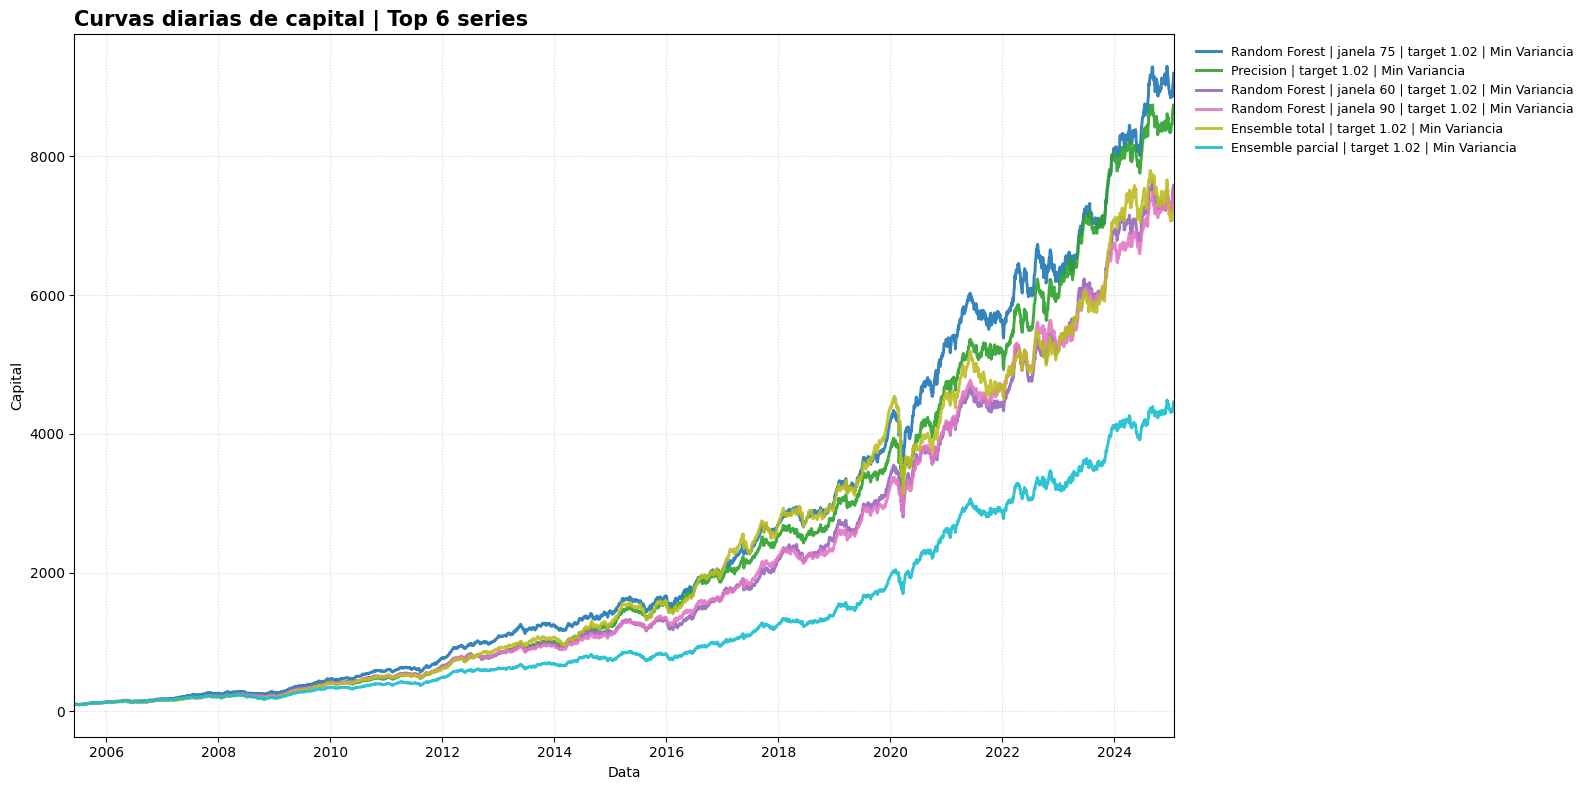

In [599]:
plot_top6_daily_curves()


In [600]:
RETORNO_CMAP = LinearSegmentedColormap.from_list(
    "retorno_mensal",
    ["#7f1d1d", "#c2410c", "#d6c7a1", "#2f855a", "#14532d"],
    N=256,
)

TRANS_CMAP = LinearSegmentedColormap.from_list(
    "transacoes_mensais",
    ["#dbeafe", "#60a5fa", "#1d4ed8", "#1e3a8a"],
    N=256,
)


def calcular_escala_global(infos, metric_col):
    valores = []

    for info in infos:
        if metric_col not in info["monthly"].columns:
            continue

        serie = pd.to_numeric(info["monthly"][metric_col], errors="coerce").dropna()
        if not serie.empty:
            valores.extend(serie.tolist())

    if not valores:
        return {"vmin": 0.0, "vmax": 1.0}

    valores = np.asarray(valores, dtype=float)

    if metric_col == "rentabilidade_mensal":
        limite = float(np.nanmax(np.abs(valores)))
        limite = max(limite, 0.01)
        return {"vmin": -limite, "vmax": limite}

    vmax = float(np.nanmax(valores))
    vmax = max(vmax, 1.0)
    return {"vmin": 0.0, "vmax": vmax}


def montar_matriz_heatmap(monthly_df, value_col):
    base = monthly_df[["mes_referencia", value_col]].copy()
    base = base.dropna(subset=["mes_referencia"])
    base["ano"] = base["mes_referencia"].dt.year
    base["mes"] = base["mes_referencia"].dt.month

    matriz = base.pivot(index="ano", columns="mes", values=value_col)
    matriz = matriz.reindex(columns=list(range(1, 13)))
    matriz = matriz.sort_index(ascending=False)
    return matriz


def draw_heatmap(ax, matriz, title, value_kind, escalas):
    valores = matriz.to_numpy(dtype=float)

    if value_kind == "retorno":
        escala = escalas["rentabilidade_mensal"]
        norm = TwoSlopeNorm(vmin=escala["vmin"], vcenter=0.0, vmax=escala["vmax"])
        cmap = RETORNO_CMAP
    else:
        escala = escalas["transacoes_mensais"]
        norm = Normalize(vmin=escala["vmin"], vmax=escala["vmax"])
        cmap = TRANS_CMAP

    imagem = ax.imshow(np.ma.masked_invalid(valores), aspect="auto", cmap=cmap, norm=norm)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(range(12))
    ax.set_xticklabels([MESES_PT[m] for m in range(1, 13)], rotation=0)
    ax.set_yticks(range(len(matriz.index)))
    ax.set_yticklabels(matriz.index.astype(str))

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(matriz.index), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)
    return imagem


def plot_top6_heatmaps(metric_col, metric_label):
    infos = get_top6_infos()
    escalas = {
        "rentabilidade_mensal": calcular_escala_global(infos, "rentabilidade_mensal"),
        "transacoes_mensais": calcular_escala_global(infos, "transacoes_mensais"),
    }

    ncols = 3
    nrows = math.ceil(len(infos) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharex=True, sharey=True)
    fig.subplots_adjust(top=0.90, bottom=0.08, wspace=0.18, hspace=0.30)
    axes = np.atleast_1d(axes).ravel()
    last_image = None

    for ax, info in zip(axes, infos):
        matriz = montar_matriz_heatmap(info["monthly"], metric_col)
        last_image = draw_heatmap(
            ax,
            matriz,
            info["serie_label"],
            "retorno" if metric_col == "rentabilidade_mensal" else "transacoes",
            escalas,
        )

    for ax in axes[len(infos):]:
        ax.set_visible(False)

    fig.suptitle(f"Top 6 series | {metric_label}", fontsize=15, fontweight="bold")
    cbar = fig.colorbar(last_image, ax=axes[:len(infos)], shrink=0.78, pad=0.01)
    cbar.ax.set_ylabel(metric_label)
    if metric_col == "rentabilidade_mensal":
        cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    plt.show()


## Mapas de calor de rentabilidade mensal


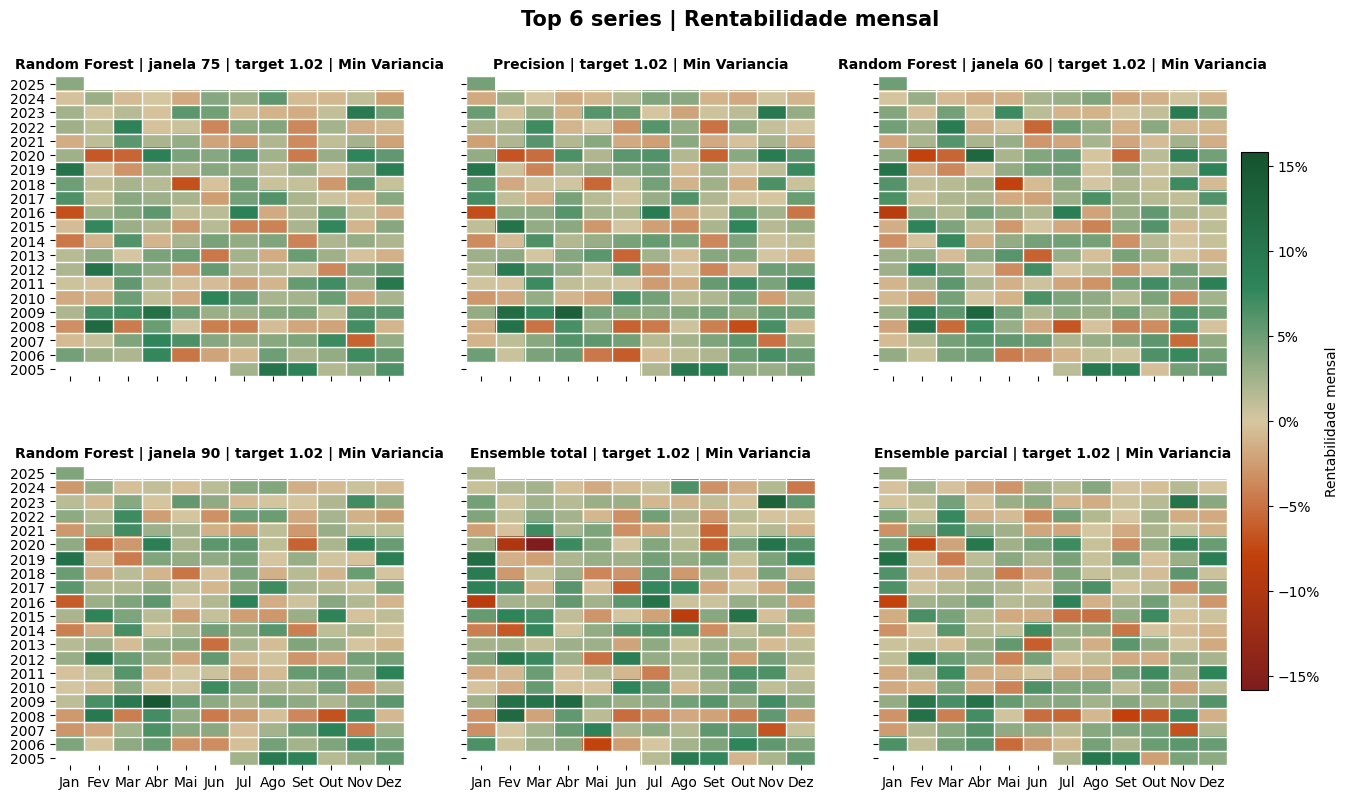

In [601]:
plot_top6_heatmaps("rentabilidade_mensal", "Rentabilidade mensal")


## Estatistica descritiva do top 6


Nesta etapa, sao reunidas medidas descritivas de atividade operacional, retorno e risco para as seis melhores series do ranking. O objetivo e complementar as comparacoes acumuladas com um retrato mais direto do comportamento diario de cada estrategia ao longo do periodo analisado.

A secao tambem incorpora o heatmap de transacoes mensais, de modo que a leitura quantitativa resumida e a distribuicao temporal das operacoes permaneçam no mesmo bloco analitico.

In [602]:
def construir_estatistica_descritiva_top6(infos, ibovespa_mensal):
    linhas = []
    ibov_base = ibovespa_mensal[["mes_referencia", "retorno_ibovespa_mensal"]].copy()
    ibov_base["mes_referencia"] = pd.to_datetime(ibov_base["mes_referencia"], errors="coerce")

    for info in infos:
        daily = info["daily"].copy().sort_values("data")
        daily["capital"] = pd.to_numeric(daily["capital"], errors="coerce")
        daily["transacoes_dia"] = pd.to_numeric(daily["transacoes_dia"], errors="coerce")
        daily["retorno_diario"] = daily["capital"].pct_change()

        monthly = info["monthly"][ ["mes_referencia", "rentabilidade_mensal"] ].copy()
        monthly["mes_referencia"] = pd.to_datetime(monthly["mes_referencia"], errors="coerce")
        comparacao_ibov = monthly.merge(ibov_base, on="mes_referencia", how="inner")
        comparacao_ibov = comparacao_ibov.dropna(subset=["rentabilidade_mensal", "retorno_ibovespa_mensal"])

        correlacao_ibov = (
            comparacao_ibov["rentabilidade_mensal"].corr(comparacao_ibov["retorno_ibovespa_mensal"])
            if len(comparacao_ibov) >= 2
            else np.nan
        )

        retorno_diario = daily["retorno_diario"].dropna()
        dias_negociacao = int(daily["data"].nunique()) if not daily.empty else 0
        transacoes_totais = float(daily["transacoes_dia"].sum()) if not daily.empty else np.nan

        linhas.append(
            {
                "serie_id": info["serie_id"],
                "serie_label": info["serie_label"],
                "dias_negociacao": dias_negociacao,
                "transacoes_totais": int(transacoes_totais) if pd.notna(transacoes_totais) else np.nan,
                "media_transacoes_dia": transacoes_totais / dias_negociacao if dias_negociacao > 0 else np.nan,
                "retorno_medio_diario": retorno_diario.mean(),
                "desvio_padrao_diario": retorno_diario.std(),
                "retorno_minimo_diario": retorno_diario.min(),
                "retorno_maximo_diario": retorno_diario.max(),
                "correlacao_pearson_ibovespa_mensal": correlacao_ibov,
            }
        )

    resumo = pd.DataFrame(linhas)
    if resumo.empty:
        return resumo

    for coluna in [
        "retorno_medio_diario",
        "desvio_padrao_diario",
        "retorno_minimo_diario",
        "retorno_maximo_diario",
    ]:
        resumo[f"{coluna}_percentual"] = resumo[coluna] * 100

    return resumo


ESTATISTICA_DESCRITIVA_TOP6 = construir_estatistica_descritiva_top6(get_top6_infos(), IBOVESPA_MENSAL)

ESTATISTICA_DESCRITIVA_TOP6[[
    "serie_label",
    "transacoes_totais",
    "media_transacoes_dia",
    "retorno_medio_diario_percentual",
    "desvio_padrao_diario_percentual",
    "retorno_minimo_diario_percentual",
    "retorno_maximo_diario_percentual",
    "correlacao_pearson_ibovespa_mensal",
]]


,serie_label,transacoes_totais,media_transacoes_dia,retorno_medio_diario_percentual,desvio_padrao_diario_percentual,retorno_minimo_diario_percentual,retorno_maximo_diario_percentual,correlacao_pearson_ibovespa_mensal
0,Random Forest | janela 75 | target 1.02 | Min ...,39515,8.125643,0.095533,0.703685,-8.859929,2.0,0.669556
1,Precision | target 1.02 | Min Variancia,38759,7.970183,0.094712,0.742206,-10.243200,2.0,0.666327
2,Random Forest | janela 60 | target 1.02 | Min ...,39522,8.127082,0.091673,0.719680,-8.859929,2.0,0.676930
3,Random Forest | janela 90 | target 1.02 | Min ...,39725,8.168826,0.091349,0.703898,-10.297469,2.0,0.680426
4,Ensemble total | target 1.02 | Min Variancia,32767,6.738022,0.091463,0.799787,-8.859929,2.0,0.682108
5,Ensemble parcial | target 1.02 | Min Variancia,39726,8.169031,0.080797,0.725046,-10.368142,2.0,0.669599


**Leitura da estatistica descritiva do top 6**

- `transacoes_totais`: numero total de transacoes contabilizadas ao longo de todo o periodo da serie.
  Esta medida ajuda a identificar o quanto a estrategia foi operacionalmente ativa no horizonte completo.
- `media_transacoes_dia`: media de transacoes por dia de negociacao.
  Esta medida ajuda a identificar a intensidade operacional media da estrategia no dia a dia.
- `retorno_medio_diario_percentual`: media aritmetica do retorno diario da serie, em percentual.
  Esta medida ajuda a identificar se, em termos medios, a estrategia tende a gerar ganhos ou perdas em cada dia observado.
- `desvio_padrao_diario_percentual`: dispersao dos retornos diarios, utilizada aqui como medida de volatilidade.
  Esta medida ajuda a identificar o grau de instabilidade da serie, isto e, o quanto os retornos diarios oscilam em torno da media.
- `retorno_minimo_diario_percentual`: pior retorno diario observado no periodo.
  Esta medida ajuda a identificar a magnitude do pior episodio diario enfrentado pela estrategia.
- `retorno_maximo_diario_percentual`: melhor retorno diario observado no periodo.
  Esta medida ajuda a identificar a magnitude do melhor episodio diario observado na serie.
- `correlacao_pearson_ibovespa_mensal`: correlacao linear entre a rentabilidade mensal da serie e a rentabilidade mensal do Ibovespa no mesmo intervalo temporal.
  Esta medida ajuda a identificar o quanto a estrategia tende a se mover na mesma direcao do mercado: valores mais proximos de `1` sugerem comportamento mais alinhado ao Ibovespa, valores proximos de `0` sugerem relacao linear fraca, e valores negativos sugerem movimento em sentido oposto.
- o heatmap de `transacoes mensais` complementa a tabela ao mostrar como essa atividade operacional se distribuiu ao longo do tempo, permitindo identificar periodos de maior e menor intensidade de alocacao.


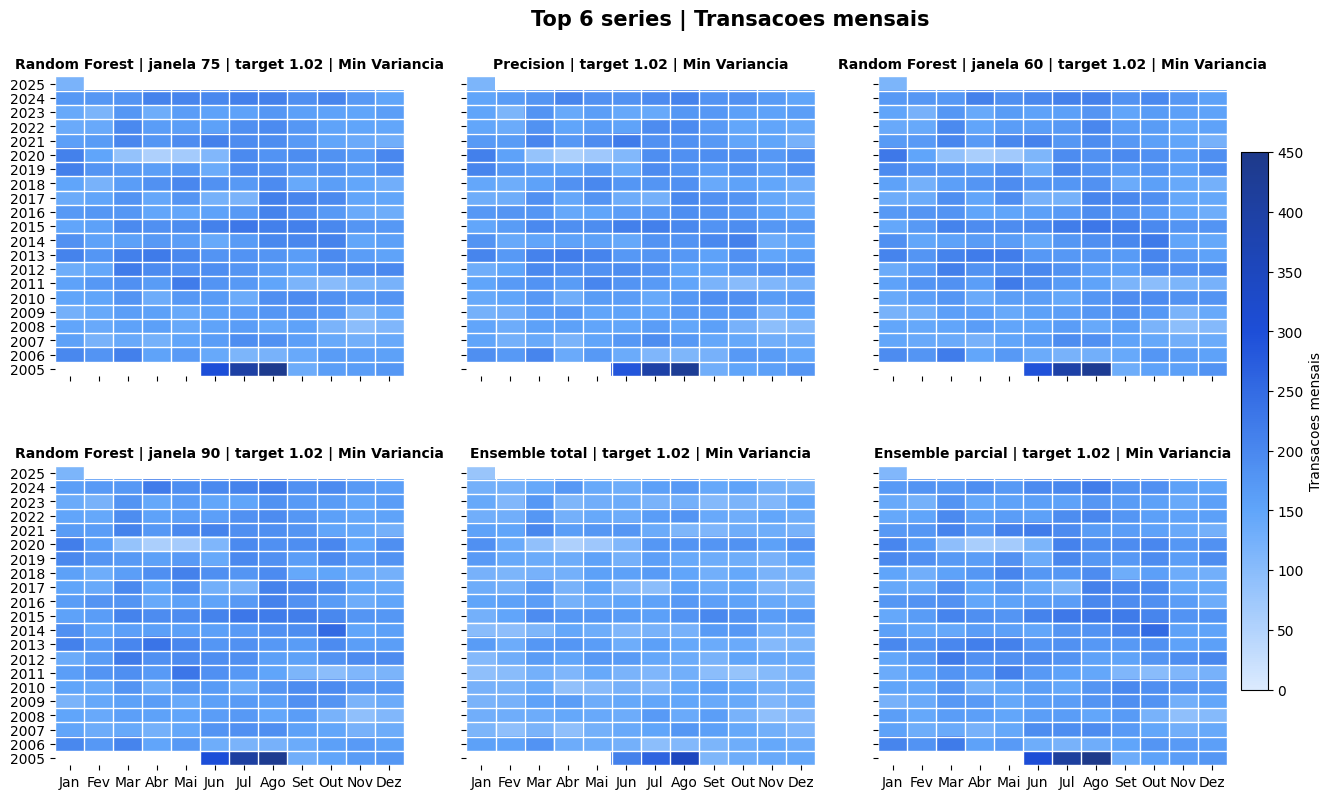

In [603]:
plot_top6_heatmaps("transacoes_mensais", "Transacoes mensais")

## Analise da cardinalidade dos portfolios

Nesta etapa, analisa-se a cardinalidade dos portfólios do top 6, entendida como o numero de ativos simultaneamente selecionados para investimento em cada dia. A proposta e avaliar se os modelos operam de forma mais concentrada ou mais diversificada ao longo do tempo, bem como verificar se as diferencas observadas entre as distribuicoes de cardinalidade media mensal sao estatisticamente relevantes.

Como as seis series sao observadas nos mesmos meses, a comparacao inferencial foi conduzida por meio do teste nao parametrico de Friedman, apropriado para amostras relacionadas. Em caso de rejeicao da hipotese nula global, realiza-se um pos-hoc com testes de Wilcoxon pareados entre os modelos, com correcao de Holm para controle de comparacoes multiplas ao nivel de 5%.


,serie_label,cardinalidade_media_geral,desvio_padrao_cardinalidade,cardinalidade_minima_observada,cardinalidade_maxima_observada,meses_avaliados
0,Ensemble parcial | target 1.02 | Min Variancia,8.170611,1.766554,0,48,236
1,Random Forest | janela 90 | target 1.02 | Min ...,8.166944,1.741898,0,47,236
2,Random Forest | janela 60 | target 1.02 | Min ...,8.126515,1.688435,0,36,236
3,Random Forest | janela 75 | target 1.02 | Min ...,8.125100,1.731272,0,37,236
4,Precision | target 1.02 | Min Variancia,7.971181,1.640000,0,34,236
5,Ensemble total | target 1.02 | Min Variancia,6.737491,1.323238,0,30,236


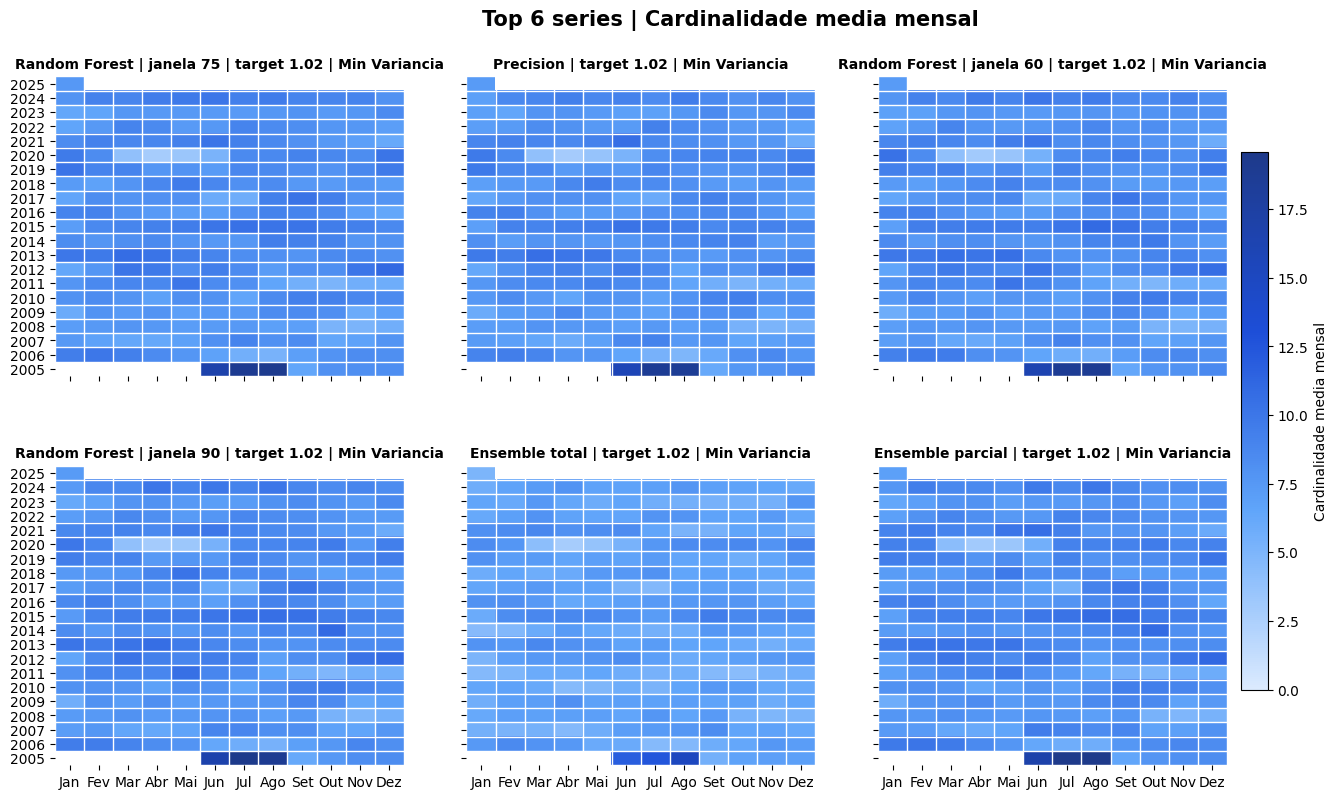

,teste,hipotese_nula,estatistica,p_valor,significativo_5pct
0,Friedman,as distribuicoes mensais de cardinalidade sao ...,476.0873,0.0000,True


,modelo_a,modelo_b,estatistica_wilcoxon,p_valor_bruto,mediana_diferenca,p_valor_ajustado_holm,significativo_5pct
0,Ensemble parcial | target 1.02 | Min Variancia,Ensemble total | target 1.02 | Min Variancia,37.5,0.0000,1.380952,0.0000,True
1,Ensemble parcial | target 1.02 | Min Variancia,Precision | target 1.02 | Min Variancia,6528.5,0.0000,0.190476,0.0000,True
2,Ensemble parcial | target 1.02 | Min Variancia,Random Forest | janela 60 | target 1.02 | Min ...,10785.0,0.0381,0.071256,0.2287,False
3,Ensemble parcial | target 1.02 | Min Variancia,Random Forest | janela 75 | target 1.02 | Min ...,10811.0,0.0517,0.095238,0.2587,False
4,Ensemble parcial | target 1.02 | Min Variancia,Random Forest | janela 90 | target 1.02 | Min ...,11944.0,0.4993,0.047619,0.9986,False
5,Ensemble total | target 1.02 | Min Variancia,Precision | target 1.02 | Min Variancia,238.0,0.0000,-1.054094,0.0000,True
6,Ensemble total | target 1.02 | Min Variancia,Random Forest | janela 60 | target 1.02 | Min ...,99.5,0.0000,-1.300000,0.0000,True
7,Ensemble total | target 1.02 | Min Variancia,Random Forest | janela 75 | target 1.02 | Min ...,181.0,0.0000,-1.261364,0.0000,True
8,Ensemble total | target 1.02 | Min Variancia,Random Forest | janela 90 | target 1.02 | Min ...,138.5,0.0000,-1.256579,0.0000,True
9,Precision | target 1.02 | Min Variancia,Random Forest | janela 60 | target 1.02 | Min ...,6560.0,0.0000,-0.120773,0.0000,True


In [604]:
def construir_cardinalidade_mensal_top6(infos):
    linhas = []
    por_serie = {}

    for info in infos:
        daily = info["daily"][["data", "transacoes_dia"]].copy().sort_values("data")
        daily["transacoes_dia"] = pd.to_numeric(daily["transacoes_dia"], errors="coerce")
        daily = daily.dropna(subset=["data", "transacoes_dia"])
        daily = daily.rename(columns={"transacoes_dia": "cardinalidade_dia"})

        monthly = (
            daily.set_index("data")
            .resample("ME")
            .agg(
                cardinalidade_media_mensal=("cardinalidade_dia", "mean"),
                cardinalidade_mediana_mensal=("cardinalidade_dia", "median"),
                cardinalidade_minima_mensal=("cardinalidade_dia", "min"),
                cardinalidade_maxima_mensal=("cardinalidade_dia", "max"),
            )
            .reset_index()
            .rename(columns={"data": "mes_referencia"})
        )

        monthly["serie_id"] = info["serie_id"]
        monthly["serie_label"] = info["serie_label"]
        linhas.append(monthly)
        por_serie[info["serie_id"]] = monthly

    detalhe = pd.concat(linhas, ignore_index=True) if linhas else pd.DataFrame()
    return detalhe, por_serie


def resumir_cardinalidade_top6(cardinalidade_detalhe):
    if cardinalidade_detalhe.empty:
        return pd.DataFrame()

    resumo = (
        cardinalidade_detalhe.groupby(["serie_id", "serie_label"], dropna=False)
        .agg(
            cardinalidade_media_geral=("cardinalidade_media_mensal", "mean"),
            desvio_padrao_cardinalidade=("cardinalidade_media_mensal", "std"),
            cardinalidade_minima_observada=("cardinalidade_minima_mensal", "min"),
            cardinalidade_maxima_observada=("cardinalidade_maxima_mensal", "max"),
            meses_avaliados=("mes_referencia", "count"),
        )
        .reset_index()
        .sort_values("cardinalidade_media_geral", ascending=False)
        .reset_index(drop=True)
    )
    return resumo


def plot_cardinalidade_top6_heatmaps(cardinalidade_por_serie):
    infos = get_top6_infos()
    valores = []
    for info in infos:
        serie = cardinalidade_por_serie.get(info["serie_id"], pd.DataFrame())
        if not serie.empty:
            valores.extend(pd.to_numeric(serie["cardinalidade_media_mensal"], errors="coerce").dropna().tolist())

    vmax = max(float(np.nanmax(valores)) if valores else 1.0, 1.0)
    escalas = {"transacoes_mensais": {"vmin": 0.0, "vmax": vmax}}

    ncols = 3
    nrows = math.ceil(len(infos) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharex=True, sharey=True)
    fig.subplots_adjust(top=0.90, bottom=0.08, wspace=0.18, hspace=0.30)
    axes = np.atleast_1d(axes).ravel()
    last_image = None

    for ax, info in zip(axes, infos):
        monthly = cardinalidade_por_serie.get(info["serie_id"], pd.DataFrame())
        matriz = montar_matriz_heatmap(monthly, "cardinalidade_media_mensal")
        last_image = draw_heatmap(ax, matriz, info["serie_label"], "transacoes", escalas)

    for ax in axes[len(infos):]:
        ax.set_visible(False)

    fig.suptitle("Top 6 series | Cardinalidade media mensal", fontsize=15, fontweight="bold")
    cbar = fig.colorbar(last_image, ax=axes[:len(infos)], shrink=0.78, pad=0.01)
    cbar.ax.set_ylabel("Cardinalidade media mensal")
    plt.show()


def testar_cardinalidade_top6(cardinalidade_detalhe):
    base = cardinalidade_detalhe[["mes_referencia", "serie_label", "cardinalidade_media_mensal"]].copy()
    base = base.dropna(subset=["mes_referencia", "serie_label", "cardinalidade_media_mensal"])

    matriz = (
        base.pivot(index="mes_referencia", columns="serie_label", values="cardinalidade_media_mensal")
        .dropna()
        .sort_index()
    )

    if matriz.empty or matriz.shape[1] < 3:
        return matriz, np.nan, np.nan, pd.DataFrame()

    estatistica, p_valor = friedmanchisquare(*[matriz[col].values for col in matriz.columns])

    pares = []
    labels = list(matriz.columns)
    for a, b in combinations(labels, 2):
        diferencas = matriz[a] - matriz[b]
        if np.allclose(diferencas, 0):
            estat_w, p_w = np.nan, 1.0
        else:
            try:
                estat_w, p_w = wilcoxon(matriz[a], matriz[b], zero_method="wilcox", alternative="two-sided", method="auto")
            except TypeError:
                estat_w, p_w = wilcoxon(matriz[a], matriz[b], zero_method="wilcox", alternative="two-sided")
            except ValueError:
                estat_w, p_w = np.nan, np.nan

        pares.append({
            "modelo_a": a,
            "modelo_b": b,
            "estatistica_wilcoxon": estat_w,
            "p_valor_bruto": p_w,
            "mediana_diferenca": np.median(diferencas),
        })

    pares = pd.DataFrame(pares)
    if not pares.empty:
        validos = pares["p_valor_bruto"].notna()
        ajustados = np.full(len(pares), np.nan)
        rejeita = np.full(len(pares), False)
        if validos.any():
            rejeita_validos, p_ajustados_validos, _, _ = multipletests(pares.loc[validos, "p_valor_bruto"], alpha=0.05, method="holm")
            ajustados[validos.to_numpy()] = p_ajustados_validos
            rejeita[validos.to_numpy()] = rejeita_validos
        pares["p_valor_ajustado_holm"] = ajustados
        pares["significativo_5pct"] = rejeita

    return matriz, estatistica, p_valor, pares


CARDINALIDADE_TOP6_DETALHE, CARDINALIDADE_TOP6_POR_SERIE = construir_cardinalidade_mensal_top6(get_top6_infos())
RESUMO_CARDINALIDADE_TOP6 = resumir_cardinalidade_top6(CARDINALIDADE_TOP6_DETALHE)
MATRIZ_CARDINALIDADE_TOP6, ESTATISTICA_FRIEDMAN_CARDINALIDADE, P_VALOR_FRIEDMAN_CARDINALIDADE, POSHOC_CARDINALIDADE_TOP6 = testar_cardinalidade_top6(CARDINALIDADE_TOP6_DETALHE)

display(RESUMO_CARDINALIDADE_TOP6[[
    "serie_label",
    "cardinalidade_media_geral",
    "desvio_padrao_cardinalidade",
    "cardinalidade_minima_observada",
    "cardinalidade_maxima_observada",
    "meses_avaliados",
]])

plot_cardinalidade_top6_heatmaps(CARDINALIDADE_TOP6_POR_SERIE)

RESUMO_TESTE_CARDINALIDADE_TOP6 = pd.DataFrame([
    {
        "teste": "Friedman",
        "hipotese_nula": "as distribuicoes mensais de cardinalidade sao iguais entre os modelos",
        "estatistica": round(ESTATISTICA_FRIEDMAN_CARDINALIDADE, 4) if pd.notna(ESTATISTICA_FRIEDMAN_CARDINALIDADE) else np.nan,
        "p_valor": f"{P_VALOR_FRIEDMAN_CARDINALIDADE:.4f}" if pd.notna(P_VALOR_FRIEDMAN_CARDINALIDADE) else "NA",
        "significativo_5pct": pd.notna(P_VALOR_FRIEDMAN_CARDINALIDADE) and P_VALOR_FRIEDMAN_CARDINALIDADE < 0.05,
    }
])

display(RESUMO_TESTE_CARDINALIDADE_TOP6)

if not POSHOC_CARDINALIDADE_TOP6.empty:
    POSHOC_CARDINALIDADE_TOP6_EXIBICAO = POSHOC_CARDINALIDADE_TOP6.copy()
    POSHOC_CARDINALIDADE_TOP6_EXIBICAO["p_valor_bruto"] = POSHOC_CARDINALIDADE_TOP6_EXIBICAO["p_valor_bruto"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "NA")
    POSHOC_CARDINALIDADE_TOP6_EXIBICAO["p_valor_ajustado_holm"] = POSHOC_CARDINALIDADE_TOP6_EXIBICAO["p_valor_ajustado_holm"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "NA")
    display(POSHOC_CARDINALIDADE_TOP6_EXIBICAO)


**Leitura do teste de hipotese para cardinalidade**

O teste global de Friedman foi utilizado para verificar se as distribuicoes mensais de cardinalidade podem ser consideradas equivalentes entre os modelos do top 6. Nesse caso, as hipoteses sao:

- `H0`: as distribuicoes mensais de cardinalidade sao iguais entre os modelos;
- `H1`: pelo menos um modelo apresenta distribuicao de cardinalidade diferente dos demais.

Quando o teste global rejeita a hipotese nula, o pos-hoc com testes de Wilcoxon pareados permite identificar quais pares de modelos apresentam diferencas estatisticamente relevantes apos a correcao de Holm. Para cada comparacao par a par, as hipoteses sao:

- `H0`: os dois modelos comparados apresentam a mesma distribuicao de cardinalidade mensal;
- `H1`: os dois modelos comparados apresentam distribuicoes de cardinalidade mensal diferentes.

Nas colunas `significativo_5pct`, os valores `True` e `False` devem ser lidos da seguinte forma:

- `True`: o `p-valor` foi menor que `0,05`, de modo que a hipotese nula foi rejeitada naquele teste;
- `False`: o `p-valor` foi maior ou igual a `0,05`, de modo que nao houve evidencia estatistica suficiente para rejeitar a hipotese nula.

Assim, essa etapa ajuda a distinguir variacoes visuais do heatmap de diferencas mais robustas do ponto de vista estatistico.


**Leitura do teste de hipotese para cardinalidade**

O teste de Friedman avalia se as distribuicoes mensais de cardinalidade podem ser consideradas equivalentes entre os modelos do top 6. A hipotese nula estabelece igualdade entre as distribuicoes, enquanto a hipotese alternativa indica que pelo menos um modelo difere dos demais.

Quando o teste global rejeita a hipotese nula, o pos-hoc com testes de Wilcoxon pareados permite identificar quais pares de modelos apresentam diferencas estatisticamente relevantes apos a correcao de Holm. Assim, essa etapa ajuda a distinguir variacoes visuais do heatmap de diferencas mais robustas do ponto de vista estatistico.


## Analise da frequencia de sinais positivos para o top 6

Nesta etapa, a frequencia de sinais positivos e analisada para as seis melhores series do ranking. A proposta consiste em quantificar com que intensidade os modelos recomendam compras ao longo do tempo, levando em conta tanto o numero de ativos disponiveis em cada dia quanto o tempo de permanencia de cada ativo no indice.

A interpretacao combina cinco dimensoes principais: o total de sinais possiveis, definido pela disponibilidade diaria de ativos elegiveis; o total de sinais positivos efetivamente gerados pelo modelo; a proporcao entre esses dois valores; a media de sinais por dia de negociacao; e a identificacao dos ativos mais frequentemente recomendados. Adicionalmente, incorpora-se uma leitura ponderada pelo tempo de permanencia no indice, de modo a evitar que ativos presentes por janelas temporais muito distintas sejam comparados de forma desbalanceada.


In [605]:
IBOV_STATUS_PATH = ROOT / "data" / "pre_process" / "ibov" / "ibov_completo_tratado.csv"


def carregar_status_ibov(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"Exchange Date": "data"})
    df["data"] = pd.to_datetime(df["data"], errors="coerce")
    return df.dropna(subset=["data"]).sort_values("data").reset_index(drop=True)


def resolver_fonte_sinais(info):
    target = info["target"]

    if info["universo"] == "tecnicas":
        caminho = ROOT / "data" / "tecnicas" / "targets_por_tecnica_tecnicas_6" / f"{info['familia']}_{info['janela']}_target_{target}.csv"
        sufixo = f"{info['familia']}_{info['janela']}"
        return caminho, sufixo

    caminho = ROOT / "data" / "ensemble" / "11_targets_por_tecnica" / f"{info['tecnica']}_target_{target}.csv"
    sufixo = info["tecnica"]
    return caminho, sufixo


def identificar_colunas_sinais(df, sufixo):
    cols = []
    for col in df.columns:
        if col in ["data"]:
            continue
        if "_rend_decisao_" in col or "_rend_venda_" in col:
            continue
        if col.endswith(f"_{sufixo}"):
            cols.append(col)
    return cols


def extrair_ativo_coluna(coluna, sufixo):
    return coluna[: -(len(sufixo) + 1)]


def analisar_sinais_serie(info, ibov_status):
    caminho, sufixo = resolver_fonte_sinais(info)
    if not caminho.exists():
        return None

    df = pd.read_csv(caminho)
    if "data" not in df.columns:
        return None

    df["data"] = pd.to_datetime(df["data"], errors="coerce")
    df = df.dropna(subset=["data"]).sort_values("data").reset_index(drop=True)

    data_inicio = pd.to_datetime(info["daily"]["data"].min(), errors="coerce")
    data_fim = pd.to_datetime(info["daily"]["data"].max(), errors="coerce")

    if pd.notna(data_inicio):
        df = df[df["data"] >= data_inicio].copy()
    if pd.notna(data_fim):
        df = df[df["data"] <= data_fim].copy()

    ibov_status = ibov_status.copy()
    if pd.notna(data_inicio):
        ibov_status = ibov_status[ibov_status["data"] >= data_inicio].copy()
    if pd.notna(data_fim):
        ibov_status = ibov_status[ibov_status["data"] <= data_fim].copy()

    colunas_sinais = identificar_colunas_sinais(df, sufixo)
    if not colunas_sinais:
        return None

    ativos = [extrair_ativo_coluna(col, sufixo) for col in colunas_sinais]
    sinais = df[["data"] + colunas_sinais].copy()
    for col in colunas_sinais:
        sinais[col] = pd.to_numeric(sinais[col], errors="coerce")

    base = sinais.merge(ibov_status[["data"] + [col for col in ativos if col in ibov_status.columns]], on="data", how="left")

    dias_negociacao = len(base)
    detalhes_ativos = []
    sinais_positivos_total = 0
    sinais_possiveis_totais = 0

    for ativo, col_sinal in zip(ativos, colunas_sinais):
        serie_sinal = pd.to_numeric(base[col_sinal], errors="coerce")

        if ativo in base.columns:
            disponibilidade = pd.to_numeric(base[ativo], errors="coerce").fillna(0)
            dias_no_indice = int((disponibilidade == 1).sum())
            sinais_positivos = int(((serie_sinal == 1) & (disponibilidade == 1)).sum())
        else:
            dias_no_indice = int(serie_sinal.notna().sum())
            sinais_positivos = int((serie_sinal == 1).sum())

        taxa_ponderada = sinais_positivos / dias_no_indice if dias_no_indice > 0 else np.nan

        sinais_positivos_total += sinais_positivos
        sinais_possiveis_totais += dias_no_indice

        detalhes_ativos.append(
            {
                "ativo": ativo,
                "dias_no_indice": dias_no_indice,
                "sinais_positivos": sinais_positivos,
                "taxa_ponderada_tempo_indice": taxa_ponderada,
            }
        )

    detalhes_ativos = pd.DataFrame(detalhes_ativos)
    detalhes_ativos = detalhes_ativos.sort_values(["sinais_positivos", "taxa_ponderada_tempo_indice"], ascending=[False, False]).reset_index(drop=True)

    ativo_com_mais_sinais = detalhes_ativos.iloc[0]["ativo"] if not detalhes_ativos.empty else None
    sinais_ativo_top = int(detalhes_ativos.iloc[0]["sinais_positivos"]) if not detalhes_ativos.empty else np.nan

    ativos_taxa = detalhes_ativos.dropna(subset=["taxa_ponderada_tempo_indice"]).sort_values("taxa_ponderada_tempo_indice", ascending=False)
    ativo_maior_taxa_ponderada = ativos_taxa.iloc[0]["ativo"] if not ativos_taxa.empty else None
    taxa_maior_ponderada = float(ativos_taxa.iloc[0]["taxa_ponderada_tempo_indice"]) if not ativos_taxa.empty else np.nan

    return {
        "serie_id": info["serie_id"],
        "serie_label": info["serie_label"],
        "grupo_label": info["grupo_label"],
        "dias_negociacao": dias_negociacao,
        "ativos_mapeados": len(ativos),
        "sinais_possiveis_totais": sinais_possiveis_totais,
        "sinais_positivos_gerados": sinais_positivos_total,
        "proporcao_sinais_positivos": sinais_positivos_total / sinais_possiveis_totais if sinais_possiveis_totais > 0 else np.nan,
        "media_sinais_por_dia": sinais_positivos_total / dias_negociacao if dias_negociacao > 0 else np.nan,
        "ativo_com_mais_sinais": ativo_com_mais_sinais,
        "sinais_ativo_top": sinais_ativo_top,
        "ativo_maior_taxa_ponderada_indice": ativo_maior_taxa_ponderada,
        "taxa_maior_ponderada_indice": taxa_maior_ponderada,
    }


IBOV_STATUS = carregar_status_ibov(IBOV_STATUS_PATH)
ANALISE_SINAIS_TOP6 = pd.DataFrame(
    [
        resultado
        for resultado in [analisar_sinais_serie(SERIES[serie_id], IBOV_STATUS) for serie_id in TOP6_SERIE_IDS if serie_id in SERIES]
        if resultado is not None
    ]
)

if not ANALISE_SINAIS_TOP6.empty:
    ANALISE_SINAIS_TOP6["proporcao_sinais_positivos_percentual"] = ANALISE_SINAIS_TOP6["proporcao_sinais_positivos"] * 100
    ANALISE_SINAIS_TOP6["taxa_maior_ponderada_indice_percentual"] = ANALISE_SINAIS_TOP6["taxa_maior_ponderada_indice"] * 100
    ANALISE_SINAIS_TOP6 = ANALISE_SINAIS_TOP6.sort_values("proporcao_sinais_positivos", ascending=False).reset_index(drop=True)

ANALISE_SINAIS_TOP6[[
    "serie_label",
    "dias_negociacao",
    "ativos_mapeados",
    "sinais_possiveis_totais",
    "sinais_positivos_gerados",
    "proporcao_sinais_positivos_percentual",
    "media_sinais_por_dia",
    "ativo_com_mais_sinais",
    "sinais_ativo_top",
    "ativo_maior_taxa_ponderada_indice",
    "taxa_maior_ponderada_indice_percentual",
]]


,serie_label,dias_negociacao,ativos_mapeados,sinais_possiveis_totais,sinais_positivos_gerados,proporcao_sinais_positivos_percentual,media_sinais_por_dia,ativo_com_mais_sinais,sinais_ativo_top,ativo_maior_taxa_ponderada_indice,taxa_maior_ponderada_indice_percentual
0,Ensemble parcial | target 1.02 | Min Variancia,4863,172,324541,214965,66.236623,44.204195,CSNA3,4004,CSTB4,89.189189
1,Random Forest | janela 90 | target 1.02 | Min ...,4863,171,324454,205941,63.473096,42.348550,CSNA3,3642,TLCP4,85.024155
2,Random Forest | janela 75 | target 1.02 | Min ...,4863,171,324454,205404,63.307588,42.238125,CSNA3,3685,TLCP4,83.574879
3,Random Forest | janela 60 | target 1.02 | Min ...,4863,172,324541,204703,63.074619,42.093975,CSNA3,3667,TLCP4,83.574879
4,Precision | target 1.02 | Min Variancia,4863,172,324541,190040,58.556546,39.078758,CSNA3,3558,AZUL4,75.630252
5,Ensemble total | target 1.02 | Min Variancia,4863,172,324541,128400,39.563568,26.403455,CSNA3,2705,CSTB4,72.072072


**Leitura das colunas da analise de sinais**

- `dias_negociacao`: quantidade de datas consideradas na analise para a serie, ja respeitando o intervalo temporal alinhado do estudo;
- `ativos_mapeados`: numero de ativos para os quais a fonte de sinais da serie possui colunas disponiveis;
- `sinais_possiveis_totais`: total de oportunidades teoricas de sinal, calculado como a soma diaria dos ativos disponiveis no indice ao longo do periodo;
- `sinais_positivos_gerados`: quantidade de vezes em que o modelo efetivamente gerou recomendacao de compra;
- `proporcao_sinais_positivos_percentual`: proporcao entre sinais positivos gerados e sinais possiveis totais, expressa em percentual;
- `media_sinais_por_dia`: media de sinais positivos emitidos por dia de negociacao;
- `ativo_com_mais_sinais`: ativo que recebeu o maior numero absoluto de sinais positivos naquela serie;
- `sinais_ativo_top`: quantidade de sinais positivos associados ao ativo com maior frequencia de recomendacao;
- `ativo_maior_taxa_ponderada_indice`: ativo com maior frequencia relativa de sinais, considerando o tempo em que permaneceu disponivel no indice;
- `taxa_maior_ponderada_indice_percentual`: percentual correspondente a essa frequencia relativa ponderada pelo tempo de permanencia no indice.


In [606]:
TESTE_IGUALDADE_PROPORCOES_SINAIS_TOP6, ESTATISTICA_PROPORCOES_SINAIS, P_VALOR_PROPORCOES_SINAIS = testar_igualdade_proporcoes_sinais(ANALISE_SINAIS_TOP6)

colunas_teste_sinais = [
    "serie_label",
    "proporcao_sinais_positivos_percentual",
    "proporcao_global_percentual",
    "desvio_em_relacao_a_global_percentual",
]

display(TESTE_IGUALDADE_PROPORCOES_SINAIS_TOP6[colunas_teste_sinais].sort_values("proporcao_sinais_positivos_percentual", ascending=False))

RESUMO_TESTE_PROPORCOES_SINAIS = pd.DataFrame([
    {
        "analise": "Frequencia de sinais positivos do top 6",
        "teste": "Teste de igualdade de proporcoes",
        "estatistica": round(ESTATISTICA_PROPORCOES_SINAIS, 4) if pd.notna(ESTATISTICA_PROPORCOES_SINAIS) else np.nan,
        "p_valor": f"{P_VALOR_PROPORCOES_SINAIS:.3f}" if pd.notna(P_VALOR_PROPORCOES_SINAIS) else "NA",
        "significativo_5pct": pd.notna(P_VALOR_PROPORCOES_SINAIS) and P_VALOR_PROPORCOES_SINAIS < 0.05,
        "significativo_1pct": pd.notna(P_VALOR_PROPORCOES_SINAIS) and P_VALOR_PROPORCOES_SINAIS < 0.01,
    }
])

display(RESUMO_TESTE_PROPORCOES_SINAIS)

significativo_sinais = pd.notna(P_VALOR_PROPORCOES_SINAIS) and P_VALOR_PROPORCOES_SINAIS < 0.05
significativo_sinais_1pct = pd.notna(P_VALOR_PROPORCOES_SINAIS) and P_VALOR_PROPORCOES_SINAIS < 0.01
acima_global = TESTE_IGUALDADE_PROPORCOES_SINAIS_TOP6.sort_values("desvio_em_relacao_a_global_percentual", ascending=False).head(2)["serie_label"].tolist()
abaixo_global = TESTE_IGUALDADE_PROPORCOES_SINAIS_TOP6.sort_values("desvio_em_relacao_a_global_percentual", ascending=True).head(2)["serie_label"].tolist()

texto_sinais = f"""
**Teste de hipoteses para frequencia de sinais positivos**

Foi aplicado um teste de igualdade de proporcoes para verificar se a frequencia de sinais positivos e a mesma entre as seis estrategias do top 6. A hipotese nula estabelece que as proporcoes de sinais positivos sao iguais entre as estrategias, enquanto a hipotese alternativa estabelece que pelo menos uma delas apresenta proporcao diferente.

O resultado produziu estatistica de teste igual a `{ESTATISTICA_PROPORCOES_SINAIS:.2f}` e `p-valor = {P_VALOR_PROPORCOES_SINAIS:.3f}`. {'Assim, rejeita-se a hipotese nula ao nivel de 1%, indicando que a intensidade de emissao de sinais positivos nao e homogenea entre as estrategias analisadas.' if significativo_sinais_1pct else ('Assim, rejeita-se a hipotese nula ao nivel de 5%, mas nao ao nivel de 1%, indicando evidencia estatistica moderada de diferenca entre as proporcoes.' if significativo_sinais else 'Assim, nao se rejeita a hipotese nula nem ao nivel de 5%, de modo que as diferencas observadas entre as proporcoes podem ser consideradas compativeis com variacao amostral.')}

As series com proporcao de sinais positivos mais acima da taxa global observada foram: {', '.join(acima_global)}. Por outro lado, as series com proporcao relativamente mais baixa em relacao ao padrao medio agregado foram: {', '.join(abaixo_global)}.
"""

display(Markdown(texto_sinais))

,serie_label,proporcao_sinais_positivos_percentual,proporcao_global_percentual,desvio_em_relacao_a_global_percentual
0,Ensemble parcial | target 1.02 | Min Variancia,66.236623,59.034951,7.201672
1,Random Forest | janela 90 | target 1.02 | Min ...,63.473096,59.034951,4.438145
2,Random Forest | janela 75 | target 1.02 | Min ...,63.307588,59.034951,4.272637
3,Random Forest | janela 60 | target 1.02 | Min ...,63.074619,59.034951,4.039668
4,Precision | target 1.02 | Min Variancia,58.556546,59.034951,-0.478405
5,Ensemble total | target 1.02 | Min Variancia,39.563568,59.034951,-19.471383


,analise,teste,estatistica,p_valor,significativo_5pct,significativo_1pct
0,Frequencia de sinais positivos do top 6,Teste de igualdade de proporcoes,65151.7797,0.000,True,True



**Teste de hipoteses para frequencia de sinais positivos**

Foi aplicado um teste de igualdade de proporcoes para verificar se a frequencia de sinais positivos e a mesma entre as seis estrategias do top 6. A hipotese nula estabelece que as proporcoes de sinais positivos sao iguais entre as estrategias, enquanto a hipotese alternativa estabelece que pelo menos uma delas apresenta proporcao diferente.

O resultado produziu estatistica de teste igual a `65151.78` e `p-valor = 0.000`. Assim, rejeita-se a hipotese nula ao nivel de 1%, indicando que a intensidade de emissao de sinais positivos nao e homogenea entre as estrategias analisadas.

As series com proporcao de sinais positivos mais acima da taxa global observada foram: Ensemble parcial | target 1.02 | Min Variancia, Random Forest | janela 90 | target 1.02 | Min Variancia. Por outro lado, as series com proporcao relativamente mais baixa em relacao ao padrao medio agregado foram: Ensemble total | target 1.02 | Min Variancia, Precision | target 1.02 | Min Variancia.


## Analise complementar dos retornos: meses de ganho vs. meses de perda

Nesta etapa, a avaliacao do top 6 e das baselines de CDI e Ibovespa e complementada por uma leitura da distribuicao dos retornos mensais entre periodos favoraveis e desfavoraveis. A proposta e identificar nao apenas o desempenho acumulado, mas tambem o padrao de recorrencia dos meses positivos e negativos e a magnitude media dos ganhos e das perdas.

Como a comparacao com os benchmarks ja esta estruturada em base mensal ao longo do notebook, a mesma frequencia foi mantida aqui para garantir consistencia metodologica entre as series analisadas.


In [607]:
def construir_retorno_mensal_top6_baselines(series, top6_ids, cdi_mensal, ibovespa_mensal):
    linhas = []

    for serie_id in top6_ids:
        if serie_id not in series:
            continue
        info = series[serie_id]
        monthly = info["monthly"][["mes_referencia", "rentabilidade_mensal"]].copy()
        monthly["serie_label"] = info["serie_label"]
        monthly = monthly.rename(columns={"rentabilidade_mensal": "retorno_mensal"})
        linhas.append(monthly[["mes_referencia", "serie_label", "retorno_mensal"]])

    base_modelos = pd.concat(linhas, ignore_index=True)
    data_inicio = base_modelos["mes_referencia"].min()
    data_fim = base_modelos["mes_referencia"].max()

    cdi_base = cdi_mensal[(cdi_mensal["mes_referencia"] >= data_inicio) & (cdi_mensal["mes_referencia"] <= data_fim)].copy()
    cdi_base["serie_label"] = "CDI"
    cdi_base = cdi_base.rename(columns={"retorno_cdi_mensal": "retorno_mensal"})

    ibov_base = ibovespa_mensal[(ibovespa_mensal["mes_referencia"] >= data_inicio) & (ibovespa_mensal["mes_referencia"] <= data_fim)].copy()
    ibov_base["serie_label"] = "Ibovespa"
    ibov_base = ibov_base.rename(columns={"retorno_ibovespa_mensal": "retorno_mensal"})

    base = pd.concat([
        base_modelos,
        cdi_base[["mes_referencia", "serie_label", "retorno_mensal"]],
        ibov_base[["mes_referencia", "serie_label", "retorno_mensal"]],
    ], ignore_index=True)

    base = base.dropna(subset=["mes_referencia", "retorno_mensal"]).sort_values(["serie_label", "mes_referencia"]).reset_index(drop=True)
    return base


def resumir_meses_ganho_perda(base_retorno_mensal):
    linhas = []

    for serie_label, grupo in base_retorno_mensal.groupby("serie_label"):
        retorno = pd.to_numeric(grupo["retorno_mensal"], errors="coerce").dropna()
        meses_total = len(retorno)
        meses_ganho = int((retorno >= 0).sum())
        meses_perda = int((retorno < 0).sum())

        linhas.append({
            "serie_label": serie_label,
            "meses_total": meses_total,
            "meses_ganho_ou_empate": meses_ganho,
            "meses_perda": meses_perda,
            "percentual_meses_ganho_ou_empate": meses_ganho / meses_total * 100 if meses_total > 0 else np.nan,
            "percentual_meses_perda": meses_perda / meses_total * 100 if meses_total > 0 else np.nan,
            "retorno_medio_meses_ganho_percentual": retorno[retorno >= 0].mean() * 100 if (retorno >= 0).any() else np.nan,
            "retorno_medio_meses_perda_percentual": retorno[retorno < 0].mean() * 100 if (retorno < 0).any() else np.nan,
            "razao_ganho_perda": meses_ganho / meses_perda if meses_perda > 0 else np.nan,
        })

    resumo = pd.DataFrame(linhas)
    ordem_series = list(ranking_capital_top6["serie_label"].tolist()) + ["CDI", "Ibovespa"]
    resumo["ordem_exibicao"] = resumo["serie_label"].map({nome: i for i, nome in enumerate(ordem_series)})
    return resumo.sort_values(["ordem_exibicao", "serie_label"]).drop(columns="ordem_exibicao").reset_index(drop=True)


BASE_RETORNO_MENSAL_TOP6_BASELINES = construir_retorno_mensal_top6_baselines(SERIES, TOP6_SERIE_IDS, CDI_MENSAL, IBOVESPA_MENSAL)
RESUMO_MESES_GANHO_PERDA = resumir_meses_ganho_perda(BASE_RETORNO_MENSAL_TOP6_BASELINES)

display(RESUMO_MESES_GANHO_PERDA)


,serie_label,meses_total,meses_ganho_ou_empate,meses_perda,percentual_meses_ganho_ou_empate,percentual_meses_perda,retorno_medio_meses_ganho_percentual,retorno_medio_meses_perda_percentual,razao_ganho_perda
0,CDI,236,236,0,100.000000,0.000000,0.821210,NaN,NaN
1,Precision | target 1.02 | Min Variancia,235,168,67,71.489362,28.510638,3.800062,-2.517846,2.507463
2,Random Forest | janela 75 | target 1.02 | Min ...,235,165,70,70.212766,29.787234,3.827520,-2.268274,2.357143
3,Ensemble total | target 1.02 | Min Variancia,235,161,74,68.510638,31.489362,4.083686,-2.731204,2.175676
4,Random Forest | janela 60 | target 1.02 | Min ...,235,159,76,67.659574,32.340426,3.899190,-2.173587,2.092105
5,Random Forest | janela 90 | target 1.02 | Min ...,235,158,77,67.234043,32.765957,3.805817,-1.935644,2.051948
6,Ensemble parcial | target 1.02 | Min Variancia,235,155,80,65.957447,34.042553,3.767686,-2.286187,1.937500
7,Ibovespa,236,133,103,56.355932,43.644068,5.215107,-4.683561,1.291262


**Leitura da analise de meses de ganho e meses de perda**

- `meses_total`: quantidade total de meses considerados para a serie no periodo analisado;
- `meses_ganho_ou_empate`: quantidade de meses com retorno maior ou igual a zero;
- `meses_perda`: quantidade de meses com retorno negativo;
- `percentual_meses_ganho_ou_empate`: percentual de meses em que a serie nao apresentou perda;
- `percentual_meses_perda`: percentual de meses com retorno negativo;
- `retorno_medio_meses_ganho_percentual`: retorno medio observado apenas nos meses positivos ou neutros;
- `retorno_medio_meses_perda_percentual`: retorno medio observado apenas nos meses negativos;
- `razao_ganho_perda`: relacao entre a frequencia de meses positivos ou neutros e a frequencia de meses negativos.

Em termos interpretativos, essa secao ajuda a distinguir estrategias que acumulam bom resultado por alta recorrencia de meses favoraveis daquelas que dependem de menos episodios positivos, porem com maior magnitude media de ganho.


## Retornos acumulados anuais por modelo

Nesta etapa, o desempenho do top 6 e das baselines de CDI e Ibovespa e reavaliado em base anual, com o objetivo de verificar se os resultados superiores observados no acumulado total se distribuíram de forma relativamente consistente ao longo do tempo ou se ficaram concentrados em anos especificos.

Para cada ano-calendario, calcula-se o retorno acumulado anual de cada serie por composicao dos retornos mensais disponiveis no periodo. A partir dessa base, torna-se possivel identificar a recorrencia de anos positivos, a capacidade de superar os benchmarks em diferentes contextos de mercado e a ocorrencia de reversoes abruptas apos anos muito favoraveis.


,serie_label,anos_avaliados,anos_positivos,anos_negativos,percentual_anos_positivos,anos_acima_cdi,anos_acima_ibovespa,melhor_ano_percentual,pior_ano_percentual
0,Random Forest | janela 75 | target 1.02 | Min ...,21,21,0,100.000000,19.0,16.0,75.605457,1.044124
1,Precision | target 1.02 | Min Variancia,21,20,1,95.238095,19.0,16.0,94.322634,-3.160313
2,Random Forest | janela 60 | target 1.02 | Min ...,21,21,0,100.000000,19.0,14.0,80.371951,2.523604
3,Random Forest | janela 90 | target 1.02 | Min ...,21,20,1,95.238095,18.0,16.0,82.763390,-0.704239
4,Ensemble total | target 1.02 | Min Variancia,21,20,1,95.238095,17.0,15.0,97.467834,-1.187028
5,Ensemble parcial | target 1.02 | Min Variancia,21,20,1,95.238095,18.0,15.0,80.421449,-11.167160
6,CDI,21,21,0,100.000000,NaN,0.0,15.368001,0.960139
7,Ibovespa,21,14,7,66.666667,0.0,NaN,82.657790,-41.223429


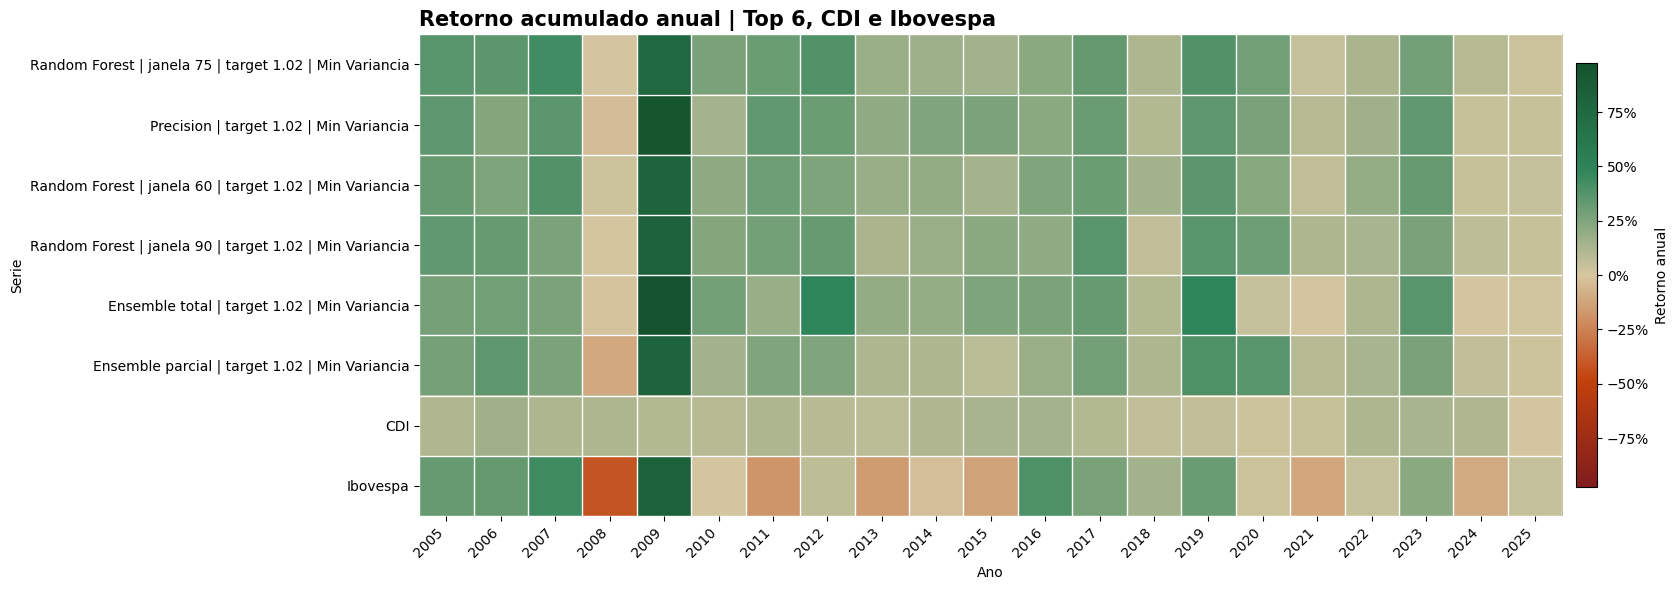

In [638]:
def construir_retorno_anual_top6_baselines(base_retorno_mensal):
    base = base_retorno_mensal.copy()
    base["mes_referencia"] = pd.to_datetime(base["mes_referencia"], errors="coerce")
    base = base.dropna(subset=["mes_referencia", "retorno_mensal"]).copy()
    base["ano"] = base["mes_referencia"].dt.year

    anual = (
        base.groupby(["serie_label", "ano"], dropna=False)
        .agg(
            retorno_anual=("retorno_mensal", lambda s: (1 + pd.to_numeric(s, errors="coerce").dropna()).prod() - 1),
            meses_no_ano=("retorno_mensal", lambda s: pd.to_numeric(s, errors="coerce").dropna().shape[0]),
        )
        .reset_index()
    )
    anual["retorno_anual_percentual"] = anual["retorno_anual"] * 100
    return anual.sort_values(["serie_label", "ano"]).reset_index(drop=True)


def resumir_consistencia_anual(retorno_anual):
    if retorno_anual.empty:
        return pd.DataFrame()

    referencia = (
        retorno_anual[retorno_anual["serie_label"].isin(["CDI", "Ibovespa"])]
        .pivot(index="ano", columns="serie_label", values="retorno_anual")
        .reset_index()
    )

    base = retorno_anual.merge(referencia, on="ano", how="left")
    modelos = base[~base["serie_label"].isin(["CDI", "Ibovespa"])].copy()

    resumo_modelos = (
        modelos.groupby("serie_label", dropna=False)
        .agg(
            anos_avaliados=("ano", "count"),
            anos_positivos=("retorno_anual", lambda s: int((pd.to_numeric(s, errors="coerce") >= 0).sum())),
            anos_negativos=("retorno_anual", lambda s: int((pd.to_numeric(s, errors="coerce") < 0).sum())),
            anos_acima_cdi=("retorno_anual", lambda s: int((pd.to_numeric(s, errors="coerce") > pd.to_numeric(modelos.loc[s.index, "CDI"], errors="coerce")).sum())),
            anos_acima_ibovespa=("retorno_anual", lambda s: int((pd.to_numeric(s, errors="coerce") > pd.to_numeric(modelos.loc[s.index, "Ibovespa"], errors="coerce")).sum())),
            melhor_ano_percentual=("retorno_anual_percentual", "max"),
            pior_ano_percentual=("retorno_anual_percentual", "min"),
        )
        .reset_index()
    )

    resumo_modelos["percentual_anos_positivos"] = np.where(
        resumo_modelos["anos_avaliados"] > 0,
        resumo_modelos["anos_positivos"] / resumo_modelos["anos_avaliados"] * 100,
        np.nan,
    )

    baselines = (
        retorno_anual[retorno_anual["serie_label"].isin(["CDI", "Ibovespa"])]
        .groupby("serie_label", dropna=False)
        .agg(
            anos_avaliados=("ano", "count"),
            anos_positivos=("retorno_anual", lambda s: int((pd.to_numeric(s, errors="coerce") >= 0).sum())),
            anos_negativos=("retorno_anual", lambda s: int((pd.to_numeric(s, errors="coerce") < 0).sum())),
            melhor_ano_percentual=("retorno_anual_percentual", "max"),
            pior_ano_percentual=("retorno_anual_percentual", "min"),
        )
        .reset_index()
    )
    baselines["anos_acima_cdi"] = np.where(baselines["serie_label"] == "CDI", np.nan, 0)
    baselines["anos_acima_ibovespa"] = np.where(baselines["serie_label"] == "Ibovespa", np.nan, 0)
    baselines["percentual_anos_positivos"] = np.where(
        baselines["anos_avaliados"] > 0,
        baselines["anos_positivos"] / baselines["anos_avaliados"] * 100,
        np.nan,
    )

    resumo = pd.concat([resumo_modelos, baselines], ignore_index=True, sort=False)
    ordem = list(ranking_capital_top6["serie_label"].tolist()) + ["CDI", "Ibovespa"]
    resumo["ordem"] = resumo["serie_label"].map({nome: i for i, nome in enumerate(ordem)})
    resumo = resumo.sort_values(["ordem", "serie_label"]).drop(columns="ordem")
    return resumo.reset_index(drop=True)


def plot_heatmap_retornos_anuais(retorno_anual):
    base = retorno_anual.copy()
    ordem_series = list(ranking_capital_top6["serie_label"].tolist()) + ["CDI", "Ibovespa"]
    matriz = (
        base.pivot(index="serie_label", columns="ano", values="retorno_anual")
        .reindex(index=ordem_series)
        .sort_index(axis=1)
    )

    valores = matriz.to_numpy(dtype=float)
    limite = float(np.nanmax(np.abs(valores))) if np.isfinite(np.nanmax(np.abs(valores))) else 0.1
    limite = max(limite, 0.05)

    fig, ax = plt.subplots(figsize=(18, max(6, 0.7 * len(matriz.index))))
    imagem = ax.imshow(
        np.ma.masked_invalid(valores),
        aspect="auto",
        cmap=RETORNO_CMAP,
        norm=TwoSlopeNorm(vmin=-limite, vcenter=0.0, vmax=limite),
    )

    ax.set_title("Retorno acumulado anual | Top 6, CDI e Ibovespa", loc="left", fontsize=15, fontweight="bold")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Serie")
    ax.set_xticks(range(len(matriz.columns)))
    ax.set_xticklabels(matriz.columns.astype(str), rotation=45, ha="right")
    ax.set_yticks(range(len(matriz.index)))
    ax.set_yticklabels(matriz.index.astype(str))

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(-0.5, len(matriz.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(matriz.index), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(imagem, ax=ax, shrink=0.88, pad=0.01)
    cbar.ax.set_ylabel("Retorno anual")
    cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    plt.tight_layout()
    plt.show()


RETORNO_ANUAL_TOP6_BASELINES = construir_retorno_anual_top6_baselines(BASE_RETORNO_MENSAL_TOP6_BASELINES)
RESUMO_CONSISTENCIA_ANUAL = resumir_consistencia_anual(RETORNO_ANUAL_TOP6_BASELINES)

display(RESUMO_CONSISTENCIA_ANUAL[[
    "serie_label",
    "anos_avaliados",
    "anos_positivos",
    "anos_negativos",
    "percentual_anos_positivos",
    "anos_acima_cdi",
    "anos_acima_ibovespa",
    "melhor_ano_percentual",
    "pior_ano_percentual",
]])

plot_heatmap_retornos_anuais(RETORNO_ANUAL_TOP6_BASELINES)


**Leitura dos retornos acumulados anuais**

- `anos_avaliados`: quantidade de anos com dados disponiveis para a serie;
- `anos_positivos`: numero de anos com retorno anual maior ou igual a zero;
- `anos_negativos`: numero de anos com retorno anual negativo;
- `percentual_anos_positivos`: participacao relativa dos anos positivos no total de anos avaliados;
- `anos_acima_cdi`: numero de anos em que o modelo superou o retorno anual do CDI;
- `anos_acima_ibovespa`: numero de anos em que o modelo superou o retorno anual do Ibovespa;
- `melhor_ano_percentual`: maior retorno anual observado na serie;
- `pior_ano_percentual`: menor retorno anual observado na serie.

O heatmap anual complementa a tabela ao mostrar se o desempenho favoravel foi relativamente distribuido ao longo do horizonte analisado ou se ficou concentrado em poucos anos excepcionais. Essa leitura tambem ajuda a identificar reversoes bruscas, isto é, anos de queda intensa que sucedem periodos de ganhos muito elevados.
